# Data Mining Project
# Predicting Honeybee Health from Hive and Weather Data

## Objectives of this Project:-

The objective of this project is to analyze hive inspection records and environmental weather data to identify patterns that are affecting honeybee colony health.

The dataset includes hive inspections, hive information, apiary locations, and weather conditions. Data mining techniques such as data cleaning, data integration, data transformation, and exploratory data analysis are applied before performing predictive modeling.

---
**Pipeline Overview:**
1. Dataset Exploration
2. Data Quality Assessment
3. Data Cleaning
4. Data Integration
5. Post-Integration Cleaning
6. Noisy Data Handling (by Binning & Smoothing)
7. Feature Aggregation
8. Feature Engineering
9. Exploratory Data Analysis & Visualizations
10. Feature Encoding & Normalization
11. Outlier Detection
12. Extracting X and y as independent variables
13. Data Reduction (using Feature Selection + PCA)

## 1. Importing Required Python Libraries

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, MinMaxScaler, StandardScaler
from sklearn.cluster import KMeans
from sklearn.ensemble import RandomForestClassifier
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_classif
from sklearn.impute import SimpleImputer

# ── Modelling Libraries ──────────────────────────────────────────────
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_score
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import (RandomForestClassifier, GradientBoostingClassifier,
                               AdaBoostClassifier)
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.svm import SVC
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                              f1_score, roc_auc_score, confusion_matrix,
                              classification_report, roc_curve, auc)
from imblearn.over_sampling import SMOTE

import warnings
warnings.filterwarnings('ignore')

## 2. Loading the Datasets

### The dataset consists of 6 relational CSV files downloaded from Kaggle.

In [ ]:
inspections         = pd.read_csv("HCC_Inspections.csv")
hive_info           = pd.read_csv("Hive_Information.csv")
apiary_info         = pd.read_csv("Apiary_Information.csv")
hourly_weather      = pd.read_csv("Hourly_Weather.csv")
weather_stations    = pd.read_csv("Weather_Stations.csv")
weather_observations = pd.read_csv("Weather_Observations.csv")

## 3. Dataset Exploration

### 3.1 Sizes of All Relational Tables (Rows × Columns)

In [ ]:
datasets = {
    'HCC_Inspections'      : inspections,
    'Hive_Information'     : hive_info,
    'Apiary_Information'   : apiary_info,
    'Hourly_Weather'       : hourly_weather,
    'Weather_Stations'     : weather_stations,
    'Weather_Observations' : weather_observations
}

for name, df in datasets.items():
    print(f"{name:26s}: {df.shape[0]} rows x {df.shape[1]} columns")

HCC_Inspections           : 2404 rows x 11 columns
Hive_Information          : 188 rows x 3 columns
Apiary_Information        : 13 rows x 4 columns
Hourly_Weather            : 3672 rows x 15 columns
Weather_Stations          : 3 rows x 3 columns
Weather_Observations      : 1776 rows x 4 columns


### 3.2 Column Names for Each Table

In [ ]:
for name, df in datasets.items():
    print(f'\n--- {name} ---')
    print(list(df.columns))


--- HCC_Inspections ---
['InpsectionID', 'HiveID', 'InsptDate', 'Brood', 'Bees', 'Queen', 'Food', 'Stressors', 'Space', 'Percent_Met', 'Healthy']

--- Hive_Information ---
['HiveID', 'Hive_Tag', 'ApiaryID']

--- Apiary_Information ---
['ApiaryID', 'Apiary', 'City', 'State']

--- Hourly_Weather ---
['WeatherID', 'ObsID', 'StationID', 'Temperature', 'Humidity', 'Dew_Point', 'Wind_Direction', 'Wind_Speed', 'Wind_Gust', 'Pressure', 'Precip', 'Condition', 'Sunrise', 'Sunset', 'Daylight_Hours']

--- Weather_Stations ---
['StationID', 'Station_City', 'Station']

--- Weather_Observations ---
['ObsID', 'Date', 'Obs_Time', 'Obs_Hour']


### 3.3 Preview of Each Table (First 5 Rows)

In [ ]:
for name, df in datasets.items():
    print(f'\n{"="*55}')
    print(f'Table: {name}')
    print(df.head().to_string())


Table: HCC_Inspections
   InpsectionID  HiveID   InsptDate  Brood  Bees  Queen  Food  Stressors  Space  Percent_Met Healthy
0             1       1  2016-06-15    1.0   1.0    1.0   1.0        0.0    1.0           83      No
1             2       1  2016-07-22    1.0   1.0    1.0   1.0        0.0    1.0           83      No
2             3       1  2016-08-01    1.0   1.0    1.0   1.0        1.0    1.0          100     Yes
3             4       1  2016-08-08    1.0   1.0    1.0   1.0        1.0    1.0          100     Yes
4             5       1  2016-08-15    1.0   1.0    1.0   1.0        0.0    1.0           83      No

Table: Hive_Information
   HiveID Hive_Tag  ApiaryID
0       1  H003-P2         1
1       2  H007-NA         1
2       3       H1         1
3       4    HT101         1
4       5    HT102         1

Table: Apiary_Information
   ApiaryID    Apiary     City State
0         1      BBCC   Durham    NC
1         2  BBCC-RTP   Durham    NC
2         3      BBTS  Clayton   

### 3.4 Data Types for Each Table

In [ ]:
for name, df in datasets.items():
    print(f'\n--- {name} ---')
    df.info()


--- HCC_Inspections ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2404 entries, 0 to 2403
Data columns (total 11 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   InpsectionID  2404 non-null   int64  
 1   HiveID        2404 non-null   int64  
 2   InsptDate     2402 non-null   object 
 3   Brood         2388 non-null   float64
 4   Bees          2388 non-null   float64
 5   Queen         2388 non-null   float64
 6   Food          2400 non-null   float64
 7   Stressors     2389 non-null   float64
 8   Space         2388 non-null   float64
 9   Percent_Met   2404 non-null   int64  
 10  Healthy       2404 non-null   object 
dtypes: float64(6), int64(3), object(2)
memory usage: 206.7+ KB

--- Hive_Information ---
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 188 entries, 0 to 187
Data columns (total 3 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   HiveID    188 non-null    int64 
 

### 3.5 Summary Statistics

In [ ]:
for name, df in datasets.items():
    print(f'\n{"="*55}')
    print(f'Summary: {name}')
    print(df.describe(include='all').to_string())


Summary: HCC_Inspections
        InpsectionID       HiveID   InsptDate        Brood         Bees        Queen         Food    Stressors        Space  Percent_Met Healthy
count    2404.000000  2404.000000        2402  2388.000000  2388.000000  2388.000000  2400.000000  2389.000000  2388.000000  2404.000000    2404
unique           NaN          NaN         335          NaN          NaN          NaN          NaN          NaN          NaN          NaN       2
top              NaN          NaN  2018-10-08          NaN          NaN          NaN          NaN          NaN          NaN          NaN      No
freq             NaN          NaN          27          NaN          NaN          NaN          NaN          NaN          NaN          NaN    1531
mean     1202.500000    92.386023         NaN     0.767797     0.866625     0.677764     0.886667     0.665969     0.868719    78.379368     NaN
std       694.119346    58.329698         NaN     0.422202     0.338353     0.466870     0.317066     0.

### 3.6 Identifying Independent and Dependent Variables

It is important to distinguish the matrix of features (i.e. the independent variables) and dependent variables from the dataset. In the HCC_Inspections table, all attributes are independent variables **except** Healthy, which is the dependent variable.

- **Independent Variables (X):** = All columns except Healthy.
- **Dependent Variable (y):** = Healthy - it represents whether the colony is healthy or not.

In [ ]:
# Extracting independent variables using iloc
# The first colon (:) takes all rows; :-1 takes all columns except the last
X_preview = inspections.iloc[:, :-1].values
print('Independent Variables (X) — first 5 rows:')
print(X_preview[:5])

# Extracting dependent variable (last column, index 10 = Healthy)
y_preview = inspections.iloc[:, 10].values
print('\nDependent Variable (y) — first 5 values:')
print(y_preview[:5])

Independent Variables (X) — first 5 rows:
[[1 1 '2016-06-15' 1.0 1.0 1.0 1.0 0.0 1.0 83]
 [2 1 '2016-07-22' 1.0 1.0 1.0 1.0 0.0 1.0 83]
 [3 1 '2016-08-01' 1.0 1.0 1.0 1.0 1.0 1.0 100]
 [4 1 '2016-08-08' 1.0 1.0 1.0 1.0 1.0 1.0 100]
 [5 1 '2016-08-15' 1.0 1.0 1.0 1.0 0.0 1.0 83]]

Dependent Variable (y) — first 5 values:
['No' 'No' 'Yes' 'Yes' 'No']


## 4. Data Quality Assessment

### 4.1 Checking Missing Values

In [ ]:
print('Missing values in each table:\n')
for name, df in datasets.items():
    missing = df.isnull().sum()
    total_missing = missing.sum()
    print(f'--- {name} (total missing: {total_missing}) ---')
    print(missing[missing > 0] if total_missing > 0 else '  No missing values')
    print()

Missing values in each table:

--- HCC_Inspections (total missing: 85) ---
InsptDate     2
Brood        16
Bees         16
Queen        16
Food          4
Stressors    15
Space        16
dtype: int64

--- Hive_Information (total missing: 1) ---
Hive_Tag    1
dtype: int64

--- Apiary_Information (total missing: 0) ---
  No missing values

--- Hourly_Weather (total missing: 154) ---
Temperature       16
Humidity          16
Dew_Point         16
Wind_Direction    26
Wind_Speed        16
Wind_Gust         16
Pressure          16
Precip            16
Condition         16
dtype: int64

--- Weather_Stations (total missing: 0) ---
  No missing values

--- Weather_Observations (total missing: 0) ---
  No missing values



### 4.2 Visualizing Missing Values

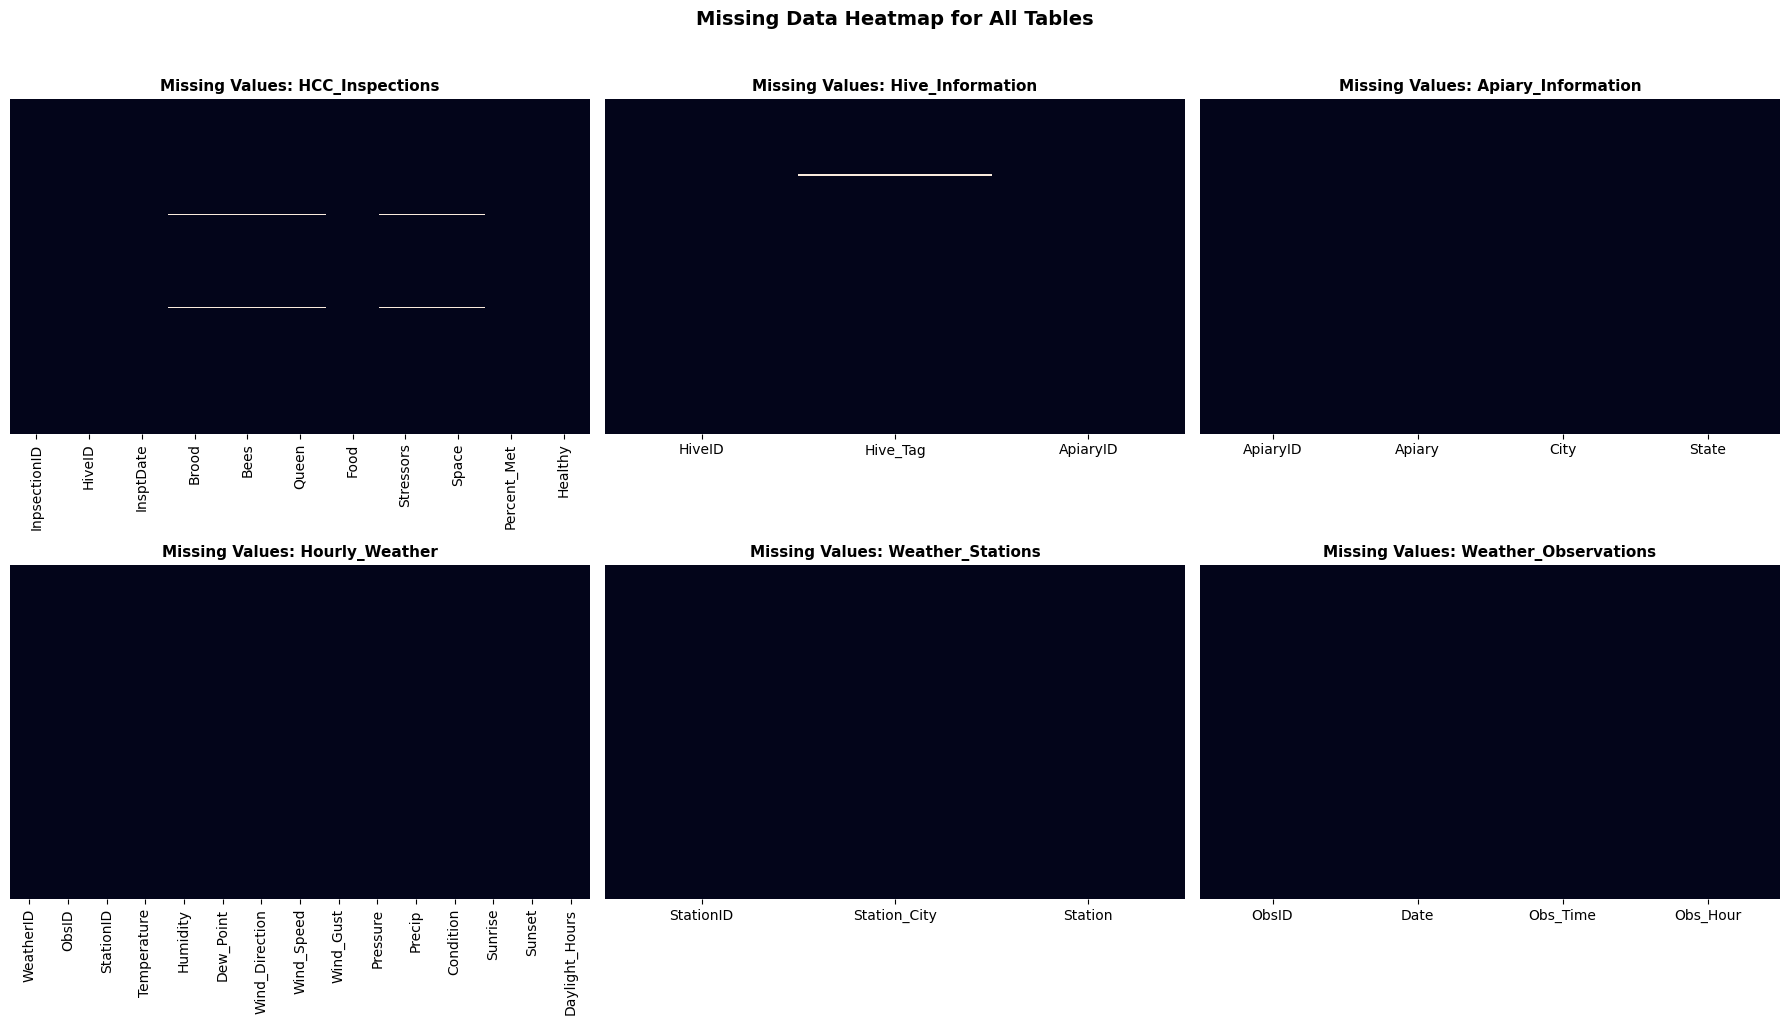

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for ax, (name, df) in zip(axes, datasets.items()):
    sns.heatmap(df.isnull(), cbar=False, ax=ax, yticklabels=False)
    ax.set_title(f'Missing Values: {name}', fontsize=11, fontweight='bold')

plt.suptitle('Missing Data Heatmap for All Tables', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 4.3 Checking for Duplicate Records

In [ ]:
print('Duplicate rows in each table:')
for name, df in datasets.items():
    dupes = df.duplicated().sum()
    print(f'  {name:26s}: {dupes} duplicates')

Duplicate rows in each table:
  HCC_Inspections           : 0 duplicates
  Hive_Information          : 0 duplicates
  Apiary_Information        : 0 duplicates
  Hourly_Weather            : 0 duplicates
  Weather_Stations          : 0 duplicates
  Weather_Observations      : 0 duplicates


## 5. Data Cleaning

### 5.1 Handling Missing Values

**Strategy used for Data Cleaning:-**
- **Categorical columns** in inspections table are filled using **mode** (which is the most frequent value)
- **Numerical columns** in hourly_weather table are filled using **mean** (which is the average value)
- **Hive_Tag** (has only 1 missing value) is filled with 'Unknown'

In [ ]:
# Categorical columns in inspections — fill with mode
inspections.fillna(inspections.mode().iloc[0], inplace=True)

# Process numerical weather columns in hourly_weather
weather_num_cols = ['Temperature', 'Humidity', 'Dew_Point', 'Wind_Speed',
                    'Wind_Gust', 'Pressure', 'Precip']

for col in weather_num_cols:
    if col in hourly_weather.columns:
        # Convert to string, replace non-numeric characters, then convert to numeric
        hourly_weather[col] = pd.to_numeric(
            hourly_weather[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True),
            errors='coerce'
        )
        # Fill NaNs with the mean of the column (if not entirely NaN), else fill with 0
        if hourly_weather[col].isnull().all():
            hourly_weather[col].fillna(0, inplace=True) # Fallback if entire column is NaN
        else:
            hourly_weather[col].fillna(hourly_weather[col].mean(), inplace=True)

# Hive_Tag — fill the 1 missing value with 'Unknown'
hive_info['Hive_Tag'].fillna('Unknown', inplace=True)

print('Missing values handled successfully.')

Missing values handled successfully.


# Remove Duplicates

In [ ]:
# Remove duplicates
inspections.drop_duplicates(inplace=True)

print('Duplicate check completed.')
print(f'inspections rows after de-duplication: {len(inspections)}')

Duplicate check completed.
inspections rows after de-duplication: 2404


### 5.3 Verifying Data Cleaning - Missing Values After Cleaning

In [ ]:
print('Missing values after cleaning:\n')
for name, df in datasets.items():
    total = df.isnull().sum().sum()
    print(f'  {name:26s}: {total} missing values remaining')


Missing values after cleaning:

  HCC_Inspections           : 0 missing values remaining
  Hive_Information          : 0 missing values remaining
  Apiary_Information        : 0 missing values remaining
  Hourly_Weather            : 42 missing values remaining
  Weather_Stations          : 0 missing values remaining
  Weather_Observations      : 0 missing values remaining


## 6. Data Integration

Data Integration is a required preprocessing step because our dataset is split into 6 relational tables. Data integration combines hive inspection data with hive details, apiary information, and weather data.

**Table Relationships:-**
```
Apiary_Information
       │ (ApiaryID)
       ▼
Hive_Information
       │ (HiveID)
       ▼
HCC_Inspections ──────────────────────────── Final Dataset
                                                    ▲
Weather_Stations                                    │
       │ (StationID)                          (InsptDate ↔ Date)
       ▼
Hourly_Weather
       │ (ObsID)
       ▼
Weather_Observations
```

### 6.1 Data Integration FlowChart

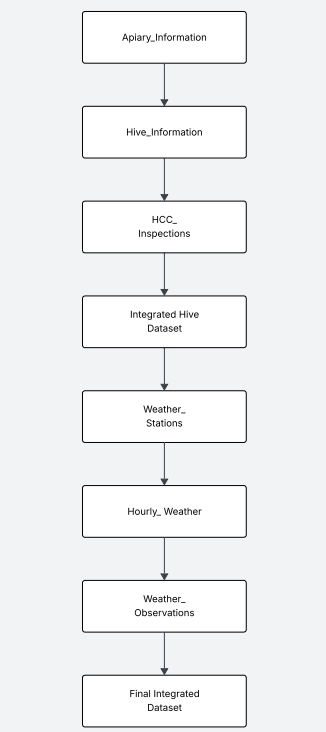

### 6.2 Step 1 - Inspecting Dataset Structure

This will help to understand schema relationships before merging them.

In [ ]:
print(inspections.head().to_string())
print('---' * 20)
print(hive_info.head().to_string())
print('---' * 20)
print(apiary_info.head().to_string())
print('---' * 20)
print(hourly_weather.head().to_string())
print('---' * 20)
print(weather_stations.head().to_string())
print('---' * 20)
print(weather_observations.head().to_string())

   InpsectionID  HiveID   InsptDate  Brood  Bees  Queen  Food  Stressors  Space  Percent_Met Healthy
0             1       1  2016-06-15    1.0   1.0    1.0   1.0        0.0    1.0           83      No
1             2       1  2016-07-22    1.0   1.0    1.0   1.0        0.0    1.0           83      No
2             3       1  2016-08-01    1.0   1.0    1.0   1.0        1.0    1.0          100     Yes
3             4       1  2016-08-08    1.0   1.0    1.0   1.0        1.0    1.0          100     Yes
4             5       1  2016-08-15    1.0   1.0    1.0   1.0        0.0    1.0           83      No
------------------------------------------------------------
   HiveID Hive_Tag  ApiaryID
0       1  H003-P2         1
1       2  H007-NA         1
2       3       H1         1
3       4    HT101         1
4       5    HT102         1
------------------------------------------------------------
   ApiaryID    Apiary     City State
0         1      BBCC   Durham    NC
1         2  BBCC-RTP   

### 6.3 Step 2 - Integrating Hive and Apiary Information

We have merged hive and apiary datasets because each hive belongs to an apiary location.

In [ ]:
hive_apiary = pd.merge(
    hive_info,
    apiary_info,
    on='ApiaryID',
    how='left'
)

print('Result: Hive Information + Apiary Location')
print('Shape of hive_apiary:', hive_apiary.shape)
print(hive_apiary.head())

Result: Hive Information + Apiary Location
Shape of hive_apiary: (188, 6)
   HiveID Hive_Tag  ApiaryID Apiary    City State
0       1  H003-P2         1   BBCC  Durham    NC
1       2  H007-NA         1   BBCC  Durham    NC
2       3       H1         1   BBCC  Durham    NC
3       4    HT101         1   BBCC  Durham    NC
4       5    HT102         1   BBCC  Durham    NC


### 6.4 Step 3 - Integrating Hive Inspection Data

We are connecting inspections with hive details so that it will merge hive_apiary with inspections.

In [ ]:
hive_full = pd.merge(
    inspections,
    hive_apiary,
    on='HiveID',
    how='left'
)

print('Result: Inspection Data + Hive Information + Apiary Location')
print('Shape of hive_full:', hive_full.shape)
print(hive_full.head())

Result: Inspection Data + Hive Information + Apiary Location
Shape of hive_full: (2404, 16)
   InpsectionID  HiveID   InsptDate  Brood  Bees  Queen  Food  Stressors  \
0             1       1  2016-06-15    1.0   1.0    1.0   1.0        0.0   
1             2       1  2016-07-22    1.0   1.0    1.0   1.0        0.0   
2             3       1  2016-08-01    1.0   1.0    1.0   1.0        1.0   
3             4       1  2016-08-08    1.0   1.0    1.0   1.0        1.0   
4             5       1  2016-08-15    1.0   1.0    1.0   1.0        0.0   

   Space  Percent_Met Healthy Hive_Tag  ApiaryID Apiary    City State  
0    1.0           83      No  H003-P2         1   BBCC  Durham    NC  
1    1.0           83      No  H003-P2         1   BBCC  Durham    NC  
2    1.0          100     Yes  H003-P2         1   BBCC  Durham    NC  
3    1.0          100     Yes  H003-P2         1   BBCC  Durham    NC  
4    1.0           83      No  H003-P2         1   BBCC  Durham    NC  


### 6.5 Step 4 - Integrating Weather Data

Weather datasets are also merged. First of all, we merged station information.

In [ ]:
weather_station_full = pd.merge(
    hourly_weather,
    weather_stations,
    on='StationID',
    how='left'
)

After this, we added observation timestamps.

In [ ]:
weather_full = pd.merge(
    weather_station_full,
    weather_observations,
    on='ObsID',
    how='left'
)

print('Result: Hourly Weather + Station Location + Observation Time')
print('Shape of weather_full:', weather_full.shape)
print(weather_full.head())

Result: Hourly Weather + Station Location + Observation Time
Shape of weather_full: (3672, 20)
   WeatherID  ObsID  StationID  Temperature  Humidity  Dew_Point  \
0          1      1          1         54.0      45.0       33.0   
1          2      2          1         52.0      47.0       32.0   
2          3      3          1         51.0      48.0       32.0   
3          4      4          1         48.0      56.0       33.0   
4          5      5          1         46.0      63.0       34.0   

  Wind_Direction  Wind_Speed  Wind_Gust  Pressure  Precip Condition  Sunrise  \
0            VAR         7.0        0.0     29.54     0.0      Fair  7:07:00   
1            NNW         3.0        0.0     29.56     0.0      Fair  7:07:00   
2           CALM         0.0        0.0     29.57     0.0      Fair  7:07:00   
3           CALM         0.0        0.0     29.57     0.0      Fair  7:07:00   
4           CALM         0.0        0.0     29.58     0.0      Fair  7:07:00   

     Sunset Day

### 6.6 Step 5 - Combining Weather with Hive Dataset

In this step, we are integrating weather conditions with hive inspections using the date attribute.

In [ ]:
hive_full['InsptDate'] = pd.to_datetime(hive_full['InsptDate'])
weather_full['Date'] = pd.to_datetime(weather_full['Date'])

final_dataset = pd.merge(
    hive_full,
    weather_full,
    left_on='InsptDate',
    right_on='Date',
    how='left'
).copy() # Add .copy() here to ensure final_dataset is a standalone DataFrame

print('Result: Hive Health + Apiary Location + Weather Conditions')
print('This is our final integrated dataset.')
print('Shape:', final_dataset.shape)
print('-' * 40)
print(final_dataset.head())

Result: Hive Health + Apiary Location + Weather Conditions
This is our final integrated dataset.
Shape: (35656, 36)
----------------------------------------
   InpsectionID  HiveID  InsptDate  Brood  Bees  Queen  Food  Stressors  \
0             1       1 2016-06-15    1.0   1.0    1.0   1.0        0.0   
1             2       1 2016-07-22    1.0   1.0    1.0   1.0        0.0   
2             3       1 2016-08-01    1.0   1.0    1.0   1.0        1.0   
3             3       1 2016-08-01    1.0   1.0    1.0   1.0        1.0   
4             3       1 2016-08-01    1.0   1.0    1.0   1.0        1.0   

   Space  Percent_Met  ... Precip   Condition  Sunrise    Sunset  \
0    1.0           83  ...    NaN         NaN      NaN       NaN   
1    1.0           83  ...    NaN         NaN      NaN       NaN   
2    1.0          100  ...    0.0  Light Rain  6:24:00  20:21:00   
3    1.0          100  ...    0.0  Light Rain  6:24:00  20:21:00   
4    1.0          100  ...    0.0  Light Rain  6:24:

### 6.7 Step 6 - Verifying Integration

This step will check missing values, feature types, and integration success in the final integrated dataset.

In [ ]:
print(final_dataset.info())
print('\nMissing values in final_dataset:')
print(final_dataset.isnull().sum().sort_values(ascending=False))

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35656 entries, 0 to 35655
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   InpsectionID    35656 non-null  int64         
 1   HiveID          35656 non-null  int64         
 2   InsptDate       35656 non-null  datetime64[ns]
 3   Brood           35656 non-null  float64       
 4   Bees            35656 non-null  float64       
 5   Queen           35656 non-null  float64       
 6   Food            35656 non-null  float64       
 7   Stressors       35656 non-null  float64       
 8   Space           35656 non-null  float64       
 9   Percent_Met     35656 non-null  int64         
 10  Healthy         35656 non-null  object        
 11  Hive_Tag        35656 non-null  object        
 12  ApiaryID        35656 non-null  int64         
 13  Apiary          35656 non-null  object        
 14  City            35656 non-null  object        
 15  St

## **Explanation of Data Integration:-**

The dataset consisted of six separate tables containing hive inspections, hive information, apiary location data, and weather records. Data integration was performed by merging hive and apiary information using ApiaryID, and connecting inspection data through HiveID. Weather datasets were merged using StationID and observation identifiers. Finally, weather conditions were linked with hive inspections using the date attribute, resulting in a unified dataset combining colony health indicators and environmental variables.

Data integration was necessary because the dataset was distributed across multiple relational tables. Merging these datasets has allowed us to combine colony inspection records with environmental conditions, as a result enabling us to do more meaningful analysis of factors affecting honeybee health.

## 7. Data Cleaning on Integrated Dataset

After data integration, it is commonly preferred to perform data cleaning again because merging datasets can introduce:-
- New missing values
- Duplicate rows
- Inconsistent data types and
- Outliers and noisy values

### 7.1 Checking Dataset Structure

In [ ]:
# Verify number of rows, columns, data types, and missing values after integration
print('Shape of final_dataset:', final_dataset.shape)
final_dataset.info()

Shape of final_dataset: (35656, 36)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 35656 entries, 0 to 35655
Data columns (total 36 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   InpsectionID    35656 non-null  int64         
 1   HiveID          35656 non-null  int64         
 2   InsptDate       35656 non-null  datetime64[ns]
 3   Brood           35656 non-null  float64       
 4   Bees            35656 non-null  float64       
 5   Queen           35656 non-null  float64       
 6   Food            35656 non-null  float64       
 7   Stressors       35656 non-null  float64       
 8   Space           35656 non-null  float64       
 9   Percent_Met     35656 non-null  int64         
 10  Healthy         35656 non-null  object        
 11  Hive_Tag        35656 non-null  object        
 12  ApiaryID        35656 non-null  int64         
 13  Apiary          35656 non-null  object        
 14  City            35

### 7.2 Checking Missing Values

In [ ]:
print('Missing values (sorted as descending order):')
print(final_dataset.isnull().sum().sort_values(ascending=False))

Missing values (sorted as descending order):
Wind_Direction    1874
Condition         1800
ObsID             1720
WeatherID         1720
Station           1720
Date              1720
Obs_Time          1720
Obs_Hour          1720
Station_City      1720
Daylight_Hours    1720
StationID         1720
Temperature       1720
Precip            1720
Pressure          1720
Wind_Gust         1720
Wind_Speed        1720
Humidity          1720
Dew_Point         1720
Sunset            1720
Sunrise           1720
Brood                0
InsptDate            0
HiveID               0
InpsectionID         0
ApiaryID             0
Apiary               0
City                 0
State                0
Stressors            0
Food                 0
Queen                0
Bees                 0
Space                0
Percent_Met          0
Healthy              0
Hive_Tag             0
dtype: int64


### 7.3 Visualizing Missing Values in Integrated Dataset

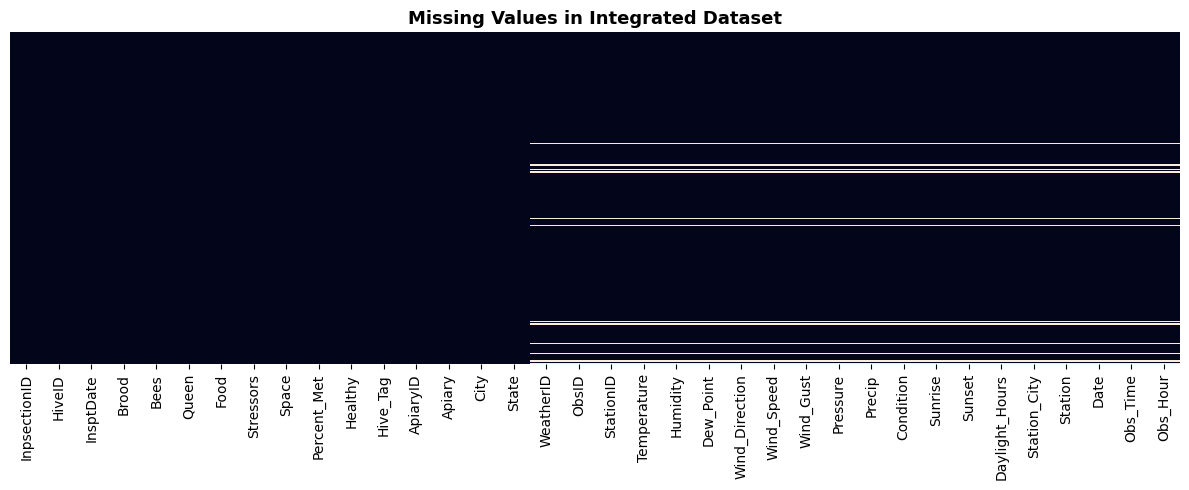

In [ ]:
plt.figure(figsize=(12, 5))
sns.heatmap(final_dataset.isnull(), cbar=False, yticklabels=False)
plt.title('Missing Values in Integrated Dataset', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 7.4 Handling Missing Values

**Numerical Columns** are filled with mean values.

In [ ]:
# Re-process weather numeric columns in final_dataset, in case new NaNs appeared from merging.
weather_features_to_clean_and_fill = ['Temperature', 'Humidity', 'Dew_Point', 'Wind_Speed',
                                       'Wind_Gust', 'Pressure', 'Precip', 'WeatherID', 'ObsID',
                                       'StationID', 'Obs_Hour']

for col in weather_features_to_clean_and_fill:
    if col in final_dataset.columns:
        # Ensure these columns are numeric (coercing errors for cleanliness)
        if final_dataset[col].dtype == 'object':
            final_dataset[col] = final_dataset[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True)
            final_dataset[col] = pd.to_numeric(final_dataset[col], errors='coerce')

# Get all numerical columns that might contain NaNs
numeric_cols_with_nans = final_dataset.select_dtypes(include=['int64', 'float64']).columns

# Calculate means for all numerical columns. For columns that are entirely NaN, their mean will be NaN.
# Then, fill those NaN means with 0, effectively filling entirely NaN columns with 0.
fill_values = final_dataset[numeric_cols_with_nans].mean().fillna(0)

# Apply fillna to the entire set of numerical columns
final_dataset[numeric_cols_with_nans] = final_dataset[numeric_cols_with_nans].fillna(fill_values)

# Handle date column separately
if 'Date' in final_dataset.columns:
    if final_dataset['Date'].dtype == 'object':
        final_dataset['Date'] = pd.to_datetime(final_dataset['Date'], errors='coerce')
    # Fill NaT values for the 'Date' column using ffill/bfill
    final_dataset['Date'] = final_dataset['Date'].ffill().bfill()

print('Missing numerical and date values in final_dataset handled successfully.')

Missing numerical and date values in final_dataset handled successfully.


**Categorical Columns** are filled with most frequent value (mode).

In [ ]:
categorical_cols = final_dataset.select_dtypes(include=['object']).columns
for col in categorical_cols:
    final_dataset[col].fillna(final_dataset[col].mode()[0], inplace=True)

print('Missing values after handling:', final_dataset.isnull().sum().sum())

Missing values after handling: 0


### 7.5 Removing Duplicate Records

In [ ]:
print('Duplicate rows:', final_dataset.duplicated().sum())
final_dataset.drop_duplicates(inplace=True)
print('Rows after dedup:', len(final_dataset))

Duplicate rows: 0
Rows after dedup: 35656


In [ ]:
print('Final Integrated Dataset Shape:', final_dataset.shape)
print('\nRemaining Missing Values:')
missing_remaining = final_dataset.isnull().sum()
has_missing = missing_remaining[missing_remaining > 0]
print(has_missing if len(has_missing) > 0 else '  None - dataset is clean.')

Final Integrated Dataset Shape: (35656, 36)

Remaining Missing Values:
  None - dataset is clean.


In [ ]:
final_dataset['Date'] = pd.to_datetime(final_dataset['Date'], errors='coerce')

# Verify
print('Date-related column dtypes:')
print(final_dataset[['InsptDate', 'Date']].dtypes)

Date-related column dtypes:
InsptDate    datetime64[ns]
Date         datetime64[ns]
dtype: object


### 7.7 Detecting Outliers Using IQR Method

In [ ]:
numeric_only = final_dataset.select_dtypes(include=['float64', 'int64'])

Q1 = numeric_only.quantile(0.25)
Q3 = numeric_only.quantile(0.75)
IQR = Q3 - Q1

# Find outliers
outliers = ((numeric_only < (Q1 - 1.5 * IQR)) |
            (numeric_only > (Q3 + 1.5 * IQR)))

print('Number of outlier values per column (sorted):')
print(outliers.sum().sort_values(ascending=False))

Number of outlier values per column (sorted):
Space           6666
Bees            6207
Food            5633
Wind_Gust       5239
Pressure        2702
Precip          2108
Percent_Met     2088
ApiaryID        1220
Temperature      482
Wind_Speed       426
Dew_Point        218
HiveID             0
InpsectionID       0
Queen              0
Brood              0
WeatherID          0
Stressors          0
StationID          0
ObsID              0
Humidity           0
Obs_Hour           0
dtype: int64


### 7.8 Handle Outliers - Capping Extreme Values

We have capped or clipped outlier values at the IQR boundaries instead of removing entire rows, to preserve data volume.

In [ ]:
for col in numeric_only.columns:
    lower = Q1[col] - 1.5 * IQR[col]
    upper = Q3[col] + 1.5 * IQR[col]
    final_dataset[col] = final_dataset[col].clip(lower=lower, upper=upper)

print('Outliers capped. Dataset shape:', final_dataset.shape)

Outliers capped. Dataset shape: (35656, 36)


### 7.9 Validate Data Ranges
#### i.e. the Humidity should be between 0–100, Temperature should be within a realistic/feasible range.

In [ ]:
print(final_dataset.describe().to_string())

       InpsectionID        HiveID                      InsptDate         Brood     Bees         Queen     Food     Stressors    Space   Percent_Met      ApiaryID     WeatherID         ObsID     StationID   Temperature      Humidity     Dew_Point    Wind_Speed  Wind_Gust      Pressure   Precip                           Date      Obs_Hour
count  35656.000000  35656.000000                          35656  35656.000000  35656.0  35656.000000  35656.0  35656.000000  35656.0  35656.000000  35656.000000  35656.000000  35656.000000  35656.000000  35656.000000  35656.000000  35656.000000  35656.000000    35656.0  35656.000000  35656.0                          35656  35656.000000
mean     900.624495     67.319834  2017-04-17 13:38:03.419340544      0.728054      1.0      0.746088      1.0      0.489918      1.0     74.534300      3.286824   1916.358557    916.200141      1.527581     70.558623     68.938833     58.537000      6.570242        0.0     29.587101      0.0  2017-04-10 15:22:34.5434147

### 7.10 Final Data Quality Check

In [ ]:
print('Final Integrated Dataset Shape:', final_dataset.shape)
print('\nRemaining Missing Values:')
missing_remaining = final_dataset.isnull().sum()
has_missing = missing_remaining[missing_remaining > 0]
print(has_missing if len(has_missing) > 0 else '  None — dataset is clean.')

Final Integrated Dataset Shape: (35656, 36)

Remaining Missing Values:
  None — dataset is clean.


# **At this step, our preprocessing pipeline has progressed through:-**
- Data Integration
- Data Cleaning

# **The next steps will be covering:-**
- Noise Reduction (by Binning & Smoothing)
- Data Transformation
- Feature Engineering
- Data Visualization
- Data Reduction

## 8. Noise Reduction Using Binning and Smoothing

Noise reduction using binning and smoothing is a classic technique used in Data Mining. It is important especially because weather sensor readings often contain short term fluctuations and random measurement noise. Adding noise reduction has made our preprocessing aligned with Data Mining steps.

## **Methods used are:**
1. Equal Width Binning
2. Mean Smoothing within bins
3. Rolling Average (Time Series Smoothing)
4. Regression Smoothing

### 8.1 Equal Width Binning (Temperature)

Binning **groups** continuous values into **intervals** to reduce noise. This step reduces small fluctuations in temperature readings.

In [ ]:
# Create bins for temperature
final_dataset['Temp_Bin'] = pd.cut(
    final_dataset['Temperature'],
    bins=4,
    labels=['Cold', 'Moderate', 'Warm', 'Hot']
)

print('Temperature Bins sample:')
print(final_dataset[['Temperature', 'Temp_Bin']].head(10))

Temperature Bins sample:
   Temperature Temp_Bin
0    70.507019     Warm
1    70.507019     Warm
2    73.000000     Warm
3    74.000000     Warm
4    74.000000     Warm
5    73.000000     Warm
6    73.000000     Warm
7    73.000000     Warm
8    74.000000     Warm
9    75.000000     Warm


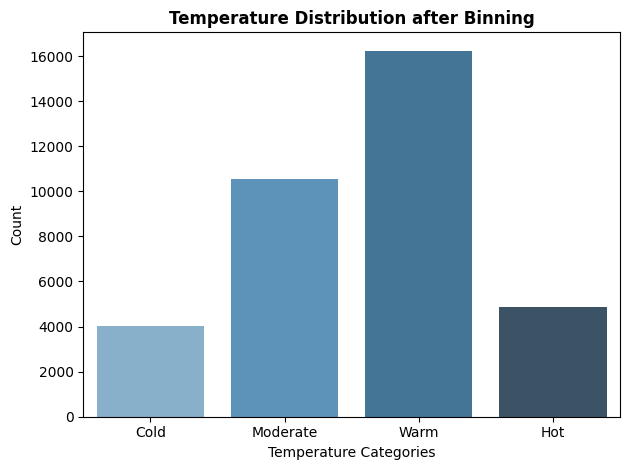

In [ ]:
sns.countplot(data=final_dataset, x='Temp_Bin', palette='Blues_d')
plt.title('Temperature Distribution after Binning', fontweight='bold')
plt.xlabel('Temperature Categories')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

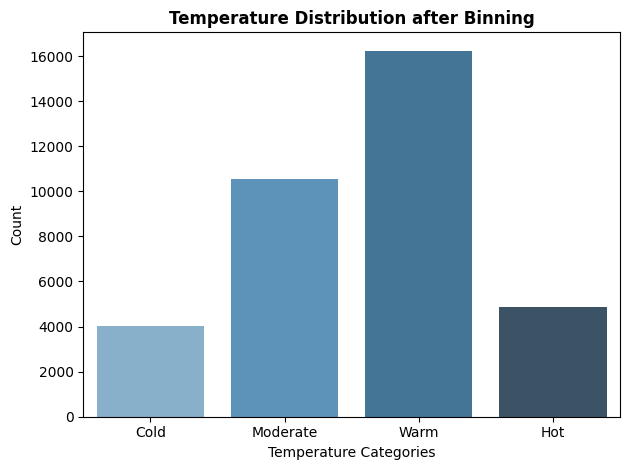

In [ ]:
sns.countplot(data=final_dataset, x='Temp_Bin', palette='Blues_d')
plt.title('Temperature Distribution after Binning', fontweight='bold')
plt.xlabel('Temperature Categories')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

### 8.3 Mean Smoothing Within Bins

#### Here we are replacing values inside each bin with the mean of the bin. This will help to removes random measurement noise.

In [ ]:
# Equal Width Binning
final_dataset['Temp_Bins'] = pd.cut(final_dataset['Temperature'], bins=5)
print('Equal Width Bins sample:')
print(final_dataset[['Temperature', 'Temp_Bins']].head())

# Equal Frequency Binning — better when data is not evenly distributed
final_dataset['Temp_Freq_Bins'] = pd.qcut(
    final_dataset['Temperature'], q=5, duplicates='drop'
)
print('\nEqual Frequency Bins sample:')
print(final_dataset[['Temperature', 'Temp_Freq_Bins']].head())

# Mean Smoothing within bins
bins_cut = pd.cut(final_dataset['Temperature'], bins=5)
final_dataset['Temp_Smoothed'] = final_dataset.groupby(
    bins_cut, observed=False
)['Temperature'].transform('mean')
print('\nSmoothed Temperature sample:')
print(final_dataset[['Temperature', 'Temp_Smoothed']].head())

Equal Width Bins sample:
   Temperature     Temp_Bins
0    70.507019  (64.2, 74.8]
1    70.507019  (64.2, 74.8]
2    73.000000  (64.2, 74.8]
3    74.000000  (64.2, 74.8]
4    74.000000  (64.2, 74.8]

Equal Frequency Bins sample:
   Temperature Temp_Freq_Bins
0    70.507019   (69.0, 73.0]
1    70.507019   (69.0, 73.0]
2    73.000000   (69.0, 73.0]
3    74.000000   (73.0, 79.0]
4    74.000000   (73.0, 79.0]

Smoothed Temperature sample:
   Temperature  Temp_Smoothed
0    70.507019      69.904328
1    70.507019      69.904328
2    73.000000      69.904328
3    74.000000      69.904328
4    74.000000      69.904328


### 8.4 Visualization of Noise Reduction

#### This step showed how smoothing reduced irregular spikes.

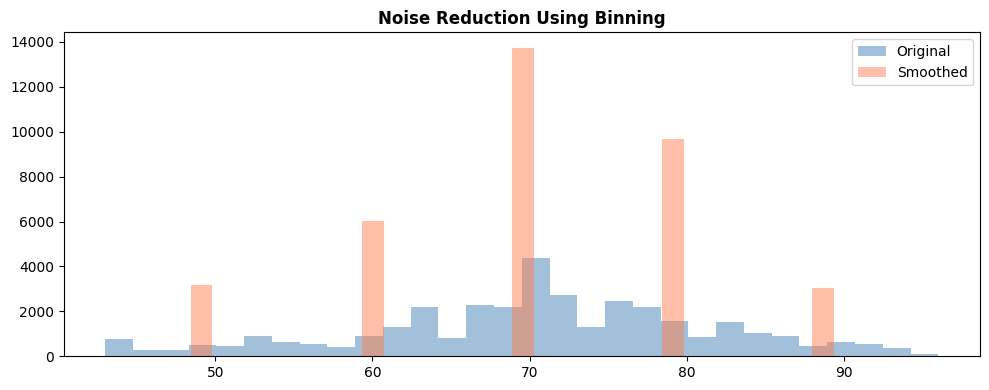

In [ ]:
plt.figure(figsize=(10, 4))
plt.hist(final_dataset['Temperature'], bins=30, alpha=0.5, label='Original', color='steelblue')
plt.hist(final_dataset['Temp_Smoothed'], bins=30, alpha=0.5, label='Smoothed', color='coral')
plt.legend()
plt.title('Noise Reduction Using Binning', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.5 Rolling Average (Time Series Smoothing)

#### Weather data often contains short term fluctuations. A rolling average smoothens the trend over a window of consecutive readings.

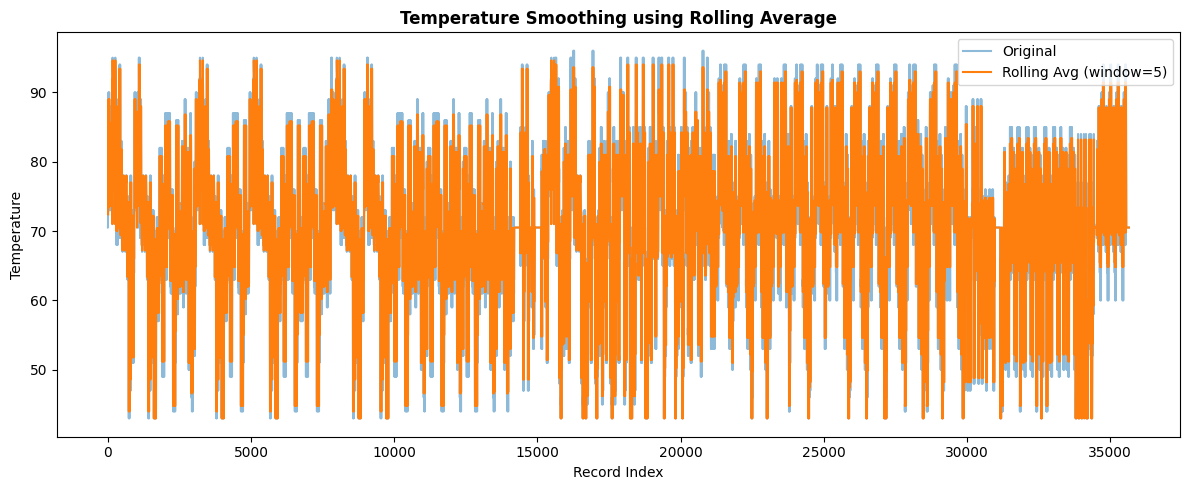

In [ ]:
final_dataset['Temp_RollingAvg'] = final_dataset['Temperature'].rolling(window=5).mean()

plt.figure(figsize=(12, 5))
plt.plot(final_dataset['Temperature'].values, label='Original', alpha=0.5)
plt.plot(final_dataset['Temp_RollingAvg'].values, label='Rolling Avg (window=5)', linewidth=1.5)
plt.legend()
plt.title('Temperature Smoothing using Rolling Average', fontweight='bold')
plt.xlabel('Record Index')
plt.ylabel('Temperature')
plt.tight_layout()
plt.show()

### 8.6 Regression Smoothing

#### We could fit a regression line to smooth noisy relationships between two variables. This has showed a smoothed relationship between Temperature and Humidity.

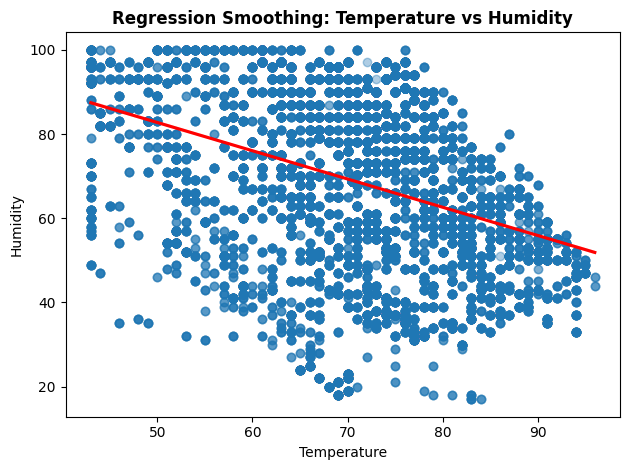

In [ ]:
sns.regplot(
    x=final_dataset['Temperature'],
    y=final_dataset['Humidity'],
    scatter_kws={'alpha': 0.2},
    line_kws={'color': 'red'}
)
plt.title('Regression Smoothing: Temperature vs Humidity', fontweight='bold')
plt.tight_layout()
plt.show()

### 8.7 Applying Mean Smoothing to All Key Weather Features

In [ ]:
weather_features = ['Temperature', 'Humidity', 'Wind_Speed', 'Pressure']

for feature in weather_features:
    if feature in final_dataset.columns:
        bins_cut = pd.cut(final_dataset[feature], bins=5)
        final_dataset[f'{feature}_Smoothed'] = final_dataset.groupby(
            bins_cut, observed=False
        )[feature].transform('mean')

print('Smoothed columns added:', [f'{f}_Smoothed' for f in weather_features])

Smoothed columns added: ['Temperature_Smoothed', 'Humidity_Smoothed', 'Wind_Speed_Smoothed', 'Pressure_Smoothed']


# **Explanation**
The noisy data in continuous attributes such as temperature was handled using binning and smoothing techniques. Binning groups data into intervals to reduce random measurement noise, whereas mean smoothing replaces individual bin values with the bin average. Rolling average smoothing reduces short term fluctuations in the time series data. All these techniques are related to the Data Mining preprocessing technique of noise handling.

# **The pipeline step where it is used is:-**
```
Data Integration → Data Cleaning → Noise Reduction (Binning & Smoothing) →
Data Transformation → Feature Engineering → Data Visualization.
```

## 9. Feature Aggregation

**Feature Aggregation** = combining hourly weather into a form that matches inspection-level records.

**Feature Engineering** = creating new meaningful variables like Hive Stress Index and Weather Stress Index.

Our hive inspections are **periodic** but weather data is **hourly**. So instead of attaching raw hourly weather rows directly, we are aggregating hourly weather into daily summaries that match each hive inspection date.

### 9.1 Step A - Converting Date Columns

In [ ]:
# Convert to datetime
final_dataset['Date'] = pd.to_datetime(final_dataset['Date'], errors='coerce')

# Before converting hourly_weather['Date'], first ensure 'Date' column exists in hourly_weather
# by merging it with weather_observations. Assuming 'ObsID' is the common column to merge.
hourly_weather = pd.merge(hourly_weather, weather_observations[['ObsID', 'Date']], on='ObsID', how='left')

# Now convert the 'Date' column in hourly_weather
hourly_weather['Date'] = pd.to_datetime(hourly_weather['Date'], errors='coerce')

### 9.2 Step B - Creating Daily Weather Aggregates

This step will convert hourly weather into daily weather features.

In [ ]:
# Convert weather columns to numeric first
for col in ['Temperature', 'Humidity', 'Wind_Speed', 'Pressure', 'Precip']:
    if col in hourly_weather.columns:
        hourly_weather[col] = pd.to_numeric(hourly_weather[col], errors='coerce')

# Create a daily date column
hourly_weather['Day'] = hourly_weather['Date'].dt.date

# Aggregate hourly weather into daily summaries
daily_weather = hourly_weather.groupby('Day').agg({
    'Temperature': ['mean', 'min', 'max'],
    'Humidity':    ['mean', 'min', 'max'],
    'Wind_Speed':  ['mean', 'max'],
    'Pressure':    ['mean'],
    'Precip':      ['sum']
}).reset_index()

### 9.3 Step C - Flatten Column Names

In [ ]:
# Flatten multi-level column names
daily_weather.columns = [
    'Day',
    'Temp_Mean', 'Temp_Min', 'Temp_Max',
    'Humidity_Mean', 'Humidity_Min', 'Humidity_Max',
    'WindSpeed_Mean', 'WindSpeed_Max',
    'Pressure_Mean',
    'Precip_Total'
]

print('Daily weather aggregates:')
print(daily_weather.head())

Daily weather aggregates:
          Day  Temp_Mean  Temp_Min  Temp_Max  Humidity_Mean  Humidity_Min  \
0  2016-03-29  55.166667      45.0      66.0      47.458333          29.0   
1  2016-04-21  66.500000      53.0      81.0      60.791667          44.0   
2  2016-04-28  70.625000      66.0      83.0      81.750000          56.0   
3  2016-05-02  72.000000      66.0      83.0      80.916667          56.0   
4  2016-05-09  70.166667      59.0      80.0      73.583333          52.0   

   Humidity_Max  WindSpeed_Mean  WindSpeed_Max  Pressure_Mean  Precip_Total  
0          71.0        3.583333           12.0      29.653333           0.0  
1          78.0        9.083333           14.0      29.679167           0.0  
2          96.0        5.500000           13.0      29.417917           1.2  
3          93.0        8.958333           22.0      29.495417           0.2  
4          93.0        1.458333            6.0      29.593750           0.2  


### 9.4 Step D - Match Daily Weather with Inspections

Now we have aligned daily weather to the inspection date.

In [ ]:
# Create inspection day column
final_dataset['Day'] = final_dataset['Date'].dt.date

# Merge aggregated weather into final_dataset
final_dataset = pd.merge(
    final_dataset,
    daily_weather,
    on='Day',
    how='left'
)

print('Shape after weather aggregation merge:', final_dataset.shape)
print(final_dataset[['Day', 'Temp_Mean', 'Humidity_Mean', 'WindSpeed_Mean']].head())

Shape after weather aggregation merge: (35656, 56)
          Day  Temp_Mean  Humidity_Mean  WindSpeed_Mean
0  2016-08-01  80.208333         80.375            5.75
1  2016-08-01  80.208333         80.375            5.75
2  2016-08-01  80.208333         80.375            5.75
3  2016-08-01  80.208333         80.375            5.75
4  2016-08-01  80.208333         80.375            5.75


## 10. Feature Engineering
### **Feature Engineering** has created new, biologically meaningful predictors from existing data.

We will be creating:-
- **Hive Stress Index** - it is a custom composite score from hive inspection conditions.
- **Weather Stress Index** - it quantifies environmental stress on colonies.
- **Combined Colony Risk Score** - it merges both indices into an overall risk indicator.

### 10.1 Hive Stress Index

Higher Hive_Stress_Index means more stressed hive whereas Lower Hive_Stress_Index means healthier hive.
If hive condition columns are text categories, we have to map them first. If they are already numeric, we can simply skip the mapping.

In [ ]:
# Mapping if values are text categories (skip if already numeric)
condition_map = {'Poor': 2, 'Average': 1, 'Good': 0}

for col in ['Queen', 'Bees', 'Brood', 'Food', 'Space']:
    if final_dataset[col].dtype == 'object':
        final_dataset[col] = final_dataset[col].map(condition_map)

# Create Hive Stress Index
final_dataset['Hive_Stress_Index'] = (
    final_dataset['Queen'].fillna(0) +
    final_dataset['Bees'].fillna(0) +
    final_dataset['Brood'].fillna(0) +
    final_dataset['Food'].fillna(0) +
    final_dataset['Space'].fillna(0)
) / 5

print('Hive Stress Index statistics:')
print(final_dataset['Hive_Stress_Index'].describe())

Hive Stress Index statistics:
count    35656.000000
mean         0.894828
std          0.154634
min          0.600000
25%          0.800000
50%          1.000000
75%          1.000000
max          1.000000
Name: Hive_Stress_Index, dtype: float64


### 10.2 Weather Stress Index

This step captures whether weather conditions are unfavorable for bees.
Stress components will include:
- **Temperature** = outside ideal bee activity range (~15°C to 30°C)
- **Humidity** = outside moderate range (~40% to 70%)
- **Wind speed** > 15 (strong winds can reduce bee flight)
- **Precipitation** > 0 (rainfall reduces foraging)

In [ ]:
# Temperature stress
final_dataset['Temp_Stress'] = np.where(
    (final_dataset['Temp_Mean'] < 15) | (final_dataset['Temp_Mean'] > 30), 1, 0
)

# Humidity stress
final_dataset['Humidity_Stress'] = np.where(
    (final_dataset['Humidity_Mean'] < 40) | (final_dataset['Humidity_Mean'] > 70), 1, 0
)

# Wind stress
final_dataset['Wind_Stress'] = np.where(
    final_dataset['WindSpeed_Mean'] > 15, 1, 0
)

# Rain stress
final_dataset['Rain_Stress'] = np.where(
    final_dataset['Precip_Total'] > 0, 1, 0
)

### 10.3 Combine into Weather Stress Index

#### Interpretation of the table,

- 0.00 is ideal weather

- 0.25–0.50 is mild stress

- 0.75–1.00 is high environmental stress

In [ ]:
# Average environmental stress score
final_dataset['Weather_Stress_Index'] = (
    final_dataset['Temp_Stress'] +
    final_dataset['Humidity_Stress'] +
    final_dataset['Wind_Stress'] +
    final_dataset['Rain_Stress']
) / 4

print('Weather Stress Index statistics:')
print(final_dataset['Weather_Stress_Index'].describe())

Weather Stress Index statistics:
count    35656.000000
mean         0.410667
std          0.183943
min          0.250000
25%          0.250000
50%          0.500000
75%          0.500000
max          1.000000
Name: Weather_Stress_Index, dtype: float64


### 10.4 Combined Colony Risk Score

Hive inspection condition is given a little higher importance (60%) than weather (40%) because it directly reflects colony status at inspection time.

In [ ]:
# Combined colony risk score
final_dataset['Colony_Risk_Score'] = (
    0.6 * final_dataset['Hive_Stress_Index'] +
    0.4 * final_dataset['Weather_Stress_Index']
)

print('Sample of engineered features:')
print(final_dataset[['Hive_Stress_Index', 'Weather_Stress_Index', 'Colony_Risk_Score']].head())

Sample of engineered features:
   Hive_Stress_Index  Weather_Stress_Index  Colony_Risk_Score
0                1.0                   0.5                0.8
1                1.0                   0.5                0.8
2                1.0                   0.5                0.8
3                1.0                   0.5                0.8
4                1.0                   0.5                0.8


### 10.5 Temperature Range Feature

In [ ]:
# Temperature Range Feature
final_dataset['Temp_Range'] = final_dataset['Temp_Max'] - final_dataset['Temp_Min']

print("Temperature Range feature added.")
print(final_dataset['Temp_Range'].describe())

Temperature Range feature added.
count    35656.000000
mean        21.156457
std          5.720249
min         11.000000
25%         17.000000
50%         21.000000
75%         25.000000
max         34.000000
Name: Temp_Range, dtype: float64


## 11. Exploratory Data Analysis (EDA) and Visualizations

### Data visualization help us in understanding distributions, relationships, and patterns in the dataset. They have include hive health characteristics and weather influence on colony health.

### 11.1 Hive Health Distribution

It shows how many colonies are healthy vs unhealthy. It helps to determine whether the dataset is balanced or if sampling techniques is required or not.

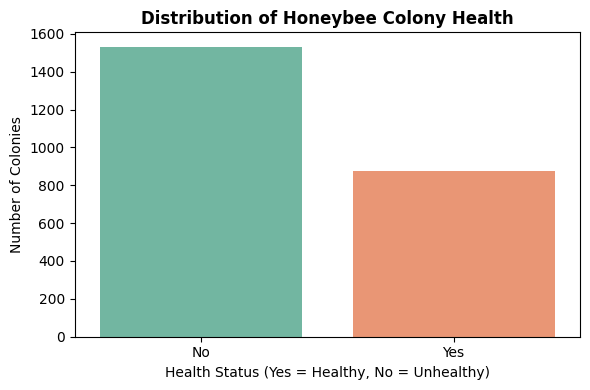

Class distribution:
Healthy
No     1531
Yes     873
Name: count, dtype: int64

Percentage:
Healthy
No     63.7
Yes    36.3
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(data=inspections, x='Healthy', palette='Set2')
plt.title('Distribution of Honeybee Colony Health', fontweight='bold')
plt.xlabel('Health Status (Yes = Healthy, No = Unhealthy)')
plt.ylabel('Number of Colonies')
plt.tight_layout()
plt.show()

print('Class distribution:')
print(inspections['Healthy'].value_counts())
print('\nPercentage:')
print(inspections['Healthy'].value_counts(normalize=True).mul(100).round(1))

### 11.2 Inspection Feature Distributions

It helped us to identify common hive problems and inspection trends.

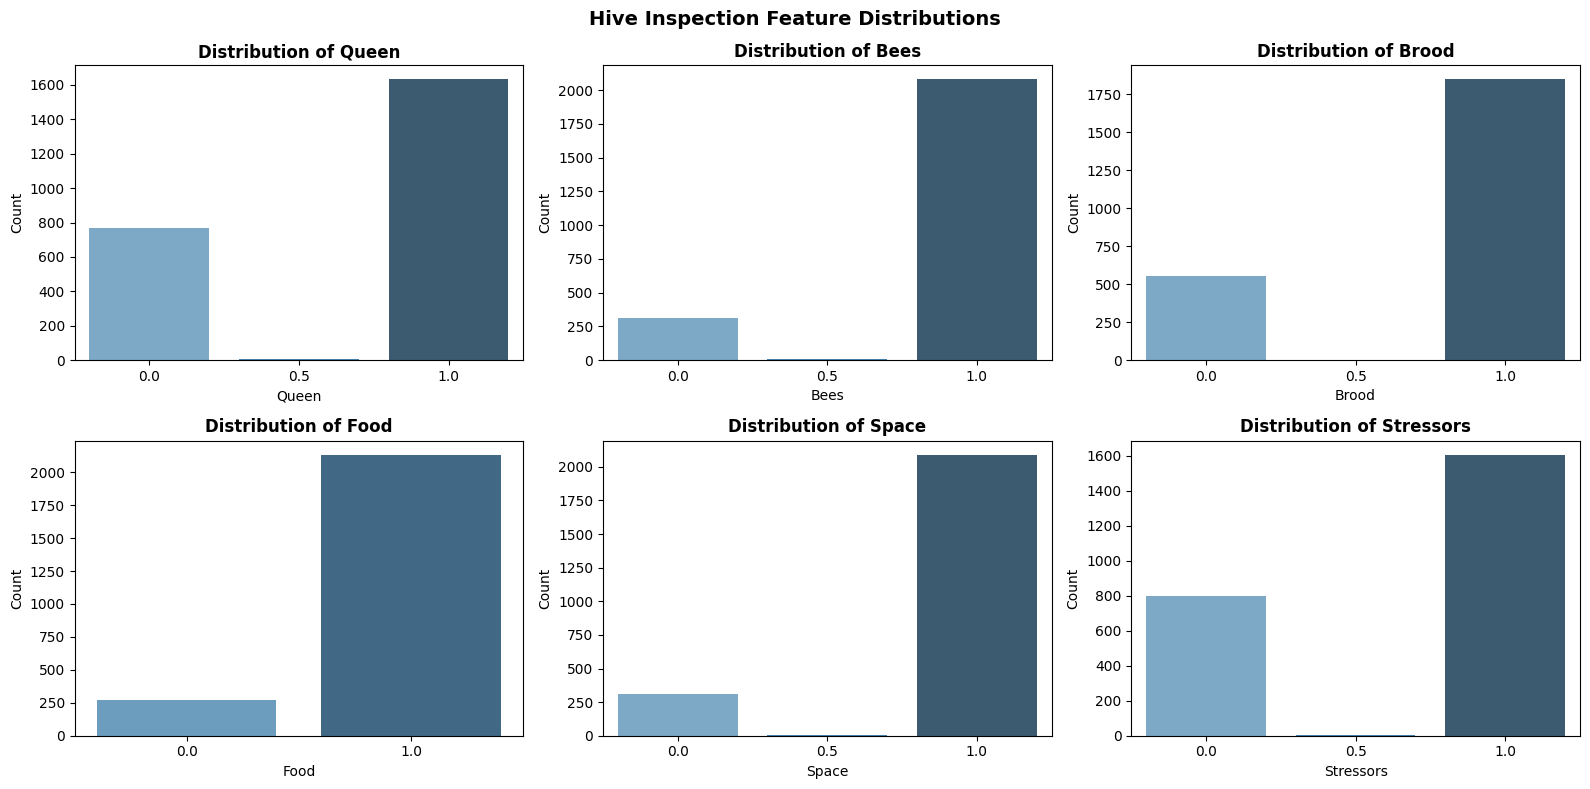

In [ ]:
inspection_cols = ['Queen', 'Bees', 'Brood', 'Food', 'Space', 'Stressors']

fig, axes = plt.subplots(2, 3, figsize=(16, 8))
axes = axes.flatten()

for ax, col in zip(axes, inspection_cols):
    sns.countplot(data=inspections, x=col, palette='Blues_d', ax=ax)
    ax.set_title(f'Distribution of {col}', fontweight='bold')
    ax.set_xlabel(col)
    ax.set_ylabel('Count')

plt.suptitle('Hive Inspection Feature Distributions', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.3 Correlation Heatmap for Honeybee Health

This is the most important visualization for our dataset features. The correlation heatmap shows relationships between inspection variables and colony health. Strong correlations indicates features that might be significantly influencing honeybee colony condition.

## **Relationships shown are:**
1. Queen condition
2. Bee population
3. Brood health
4. Food availability
5. Colony health (Healthy)

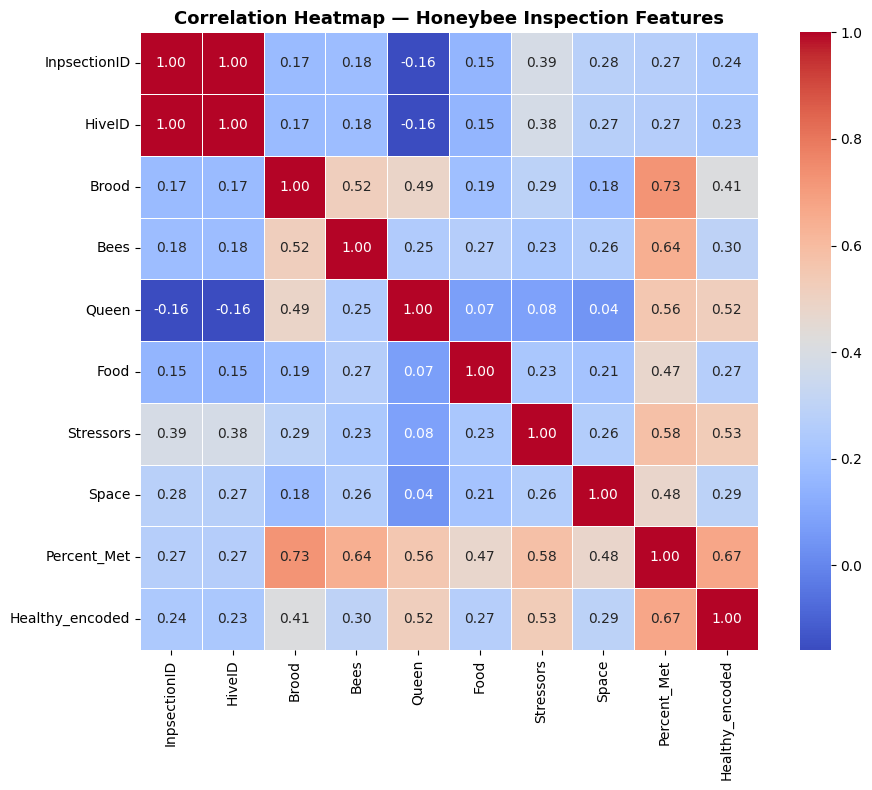

In [ ]:
# Encode Healthy for correlation
inspections_corr = inspections.copy()
le_temp = LabelEncoder()
inspections_corr['Healthy_encoded'] = le_temp.fit_transform(inspections_corr['Healthy'])

numeric_insp = inspections_corr.select_dtypes(include=['int64', 'float64'])

plt.figure(figsize=(10, 8))
sns.heatmap(
    numeric_insp.corr(),
    annot=True,
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.5,
    square=True
)
plt.title('Correlation Heatmap — Honeybee Inspection Features', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.4 Correlation Heatmap on Final Integrated Dataset

#### This heatmap has covered all features including weather variables after integration.

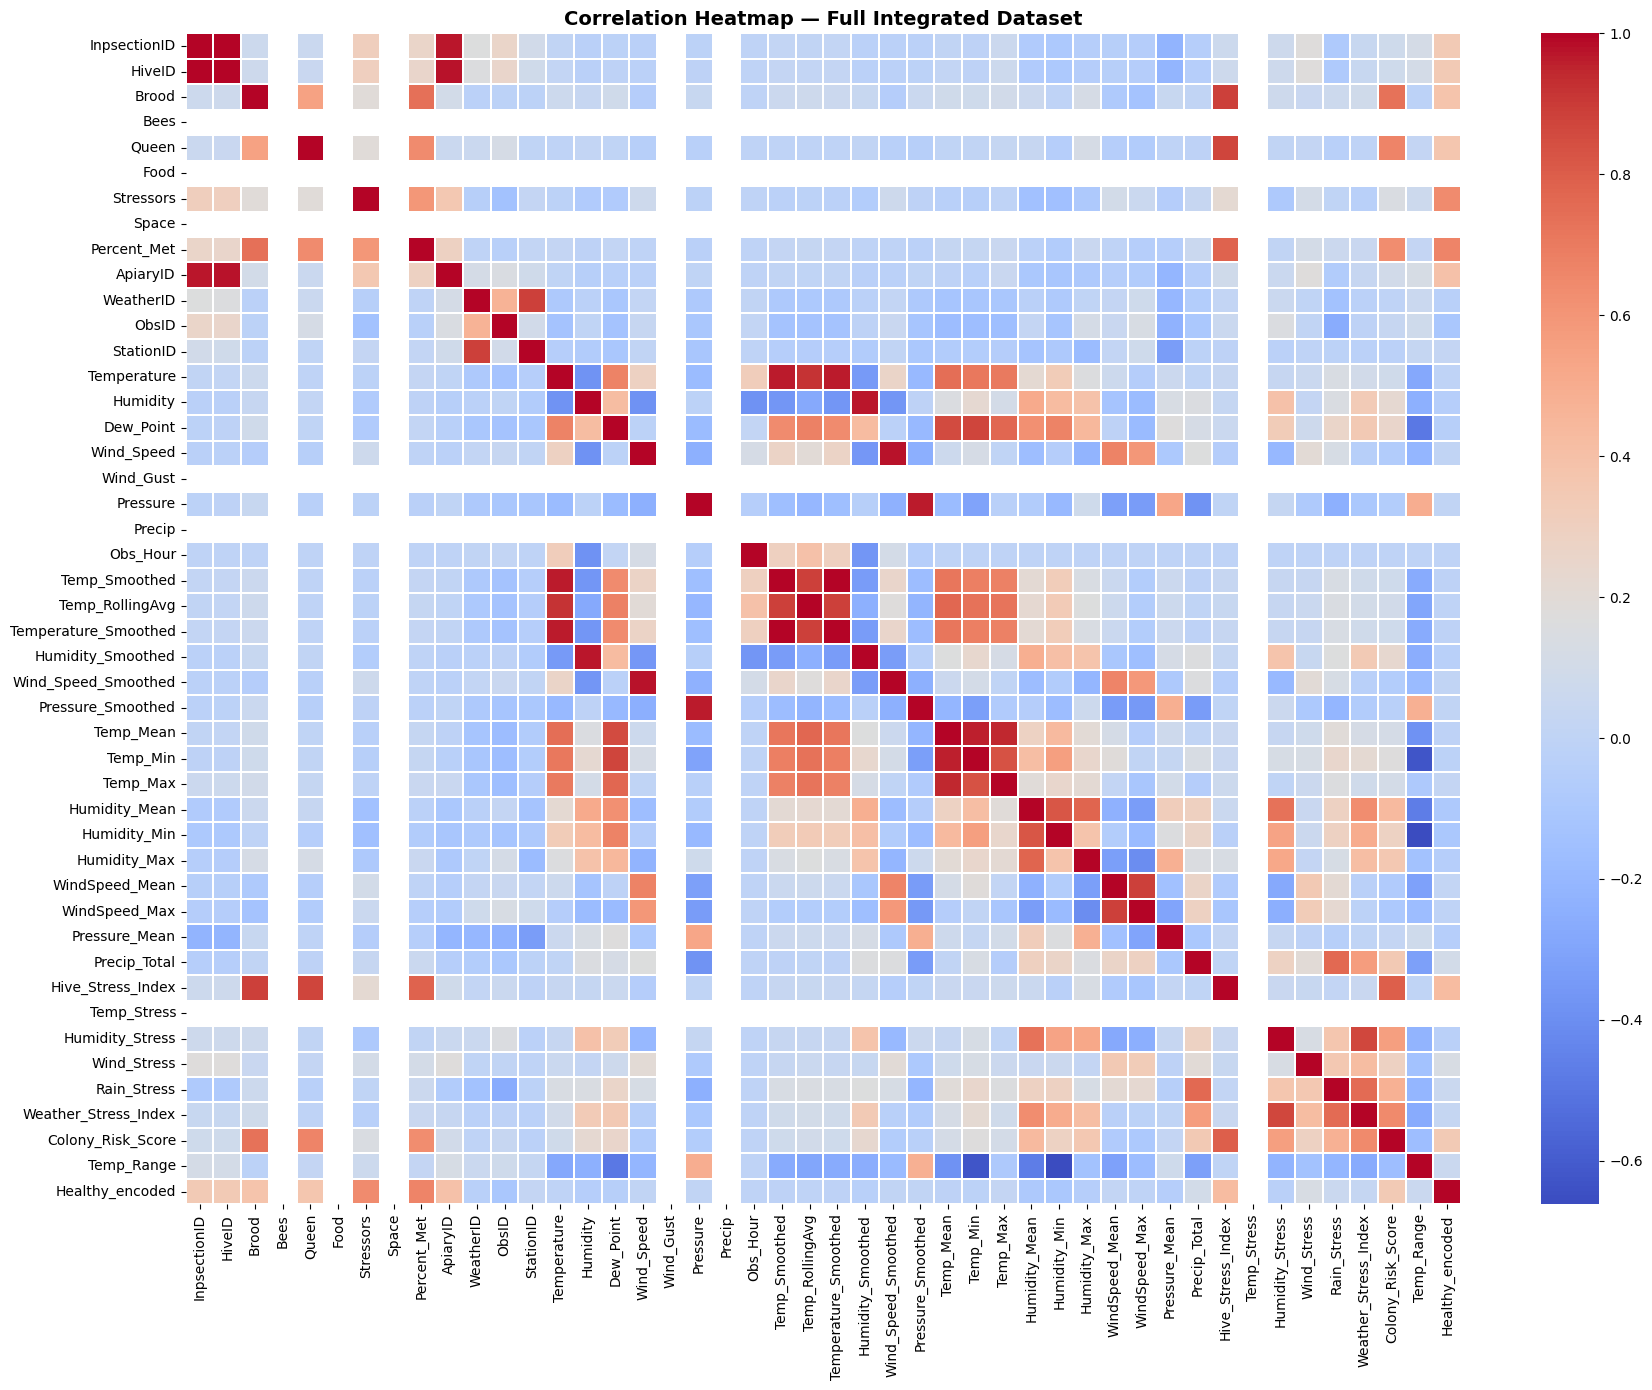

In [ ]:
# Encode Healthy in final_dataset for correlation
le_fd = LabelEncoder()
final_dataset['Healthy_encoded'] = le_fd.fit_transform(
    final_dataset['Healthy'].astype(str)
)

numeric_fd = final_dataset.select_dtypes(include=['number'])

plt.figure(figsize=(18, 14))
sns.heatmap(
    numeric_fd.corr(),
    cmap='coolwarm',
    fmt='.2f',
    linewidths=0.3,
    annot=False
)
plt.title('Correlation Heatmap — Full Integrated Dataset', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 11.5 Weather Influence Analysis - Temperature vs Hive Health

#### This will check if temperature affects colony health.

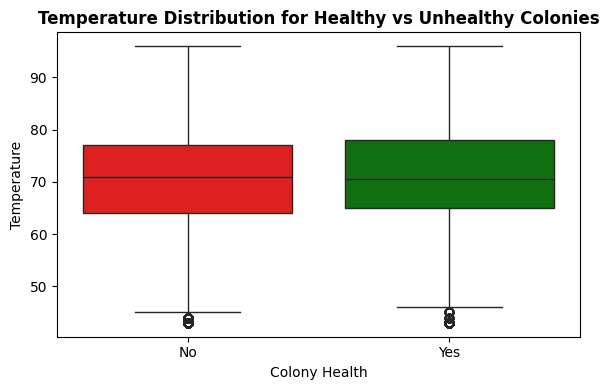

In [ ]:
plt.figure(figsize=(6, 4))
sns.boxplot(
    x='Healthy',
    y='Temperature',
    data=final_dataset,
    palette={'Yes': 'green', 'No': 'red'}
)
plt.title('Temperature Distribution for Healthy vs Unhealthy Colonies', fontweight='bold')
plt.xlabel('Colony Health')
plt.ylabel('Temperature')
plt.tight_layout()
plt.show()

### 11.6 Hive Health Trend Over Time

The main purpose of this plot is to identify seasonal patterns and colony decline periods.

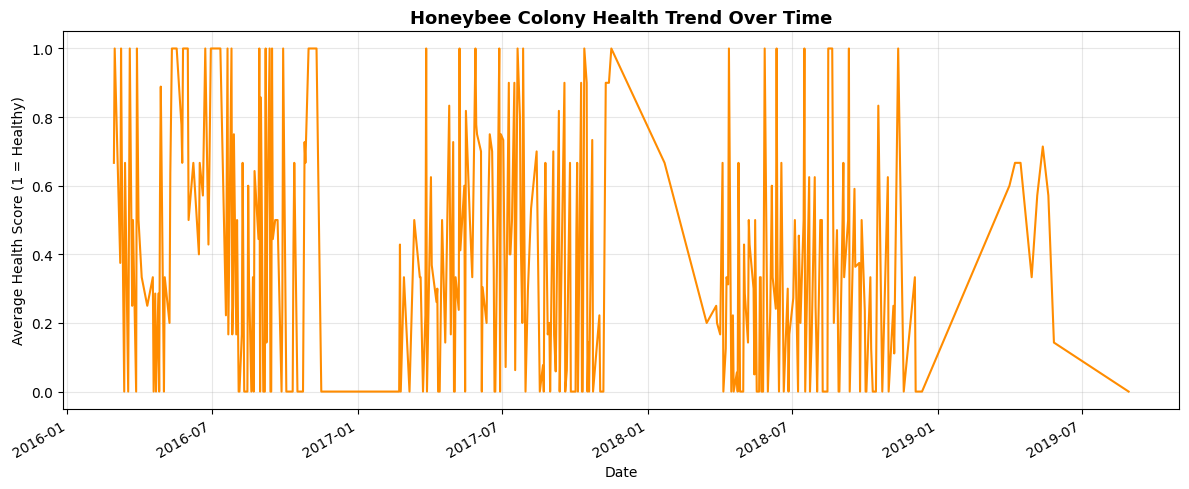

In [ ]:
inspections_ts = inspections.copy()
inspections_ts['InsptDate'] = pd.to_datetime(inspections_ts['InsptDate'])
le_ts = LabelEncoder()
inspections_ts['Healthy_encoded'] = le_ts.fit_transform(inspections_ts['Healthy'])
health_trend = inspections_ts.groupby('InsptDate')['Healthy_encoded'].mean()

plt.figure(figsize=(12, 5))
health_trend.plot(color='darkorange', linewidth=1.5)
plt.title('Honeybee Colony Health Trend Over Time', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Average Health Score (1 = Healthy)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.7 Weather Pattern Analysis - shows Average Humidity Trend Over Time

#### Because Weather trends can affect nectar availability and colony stress.

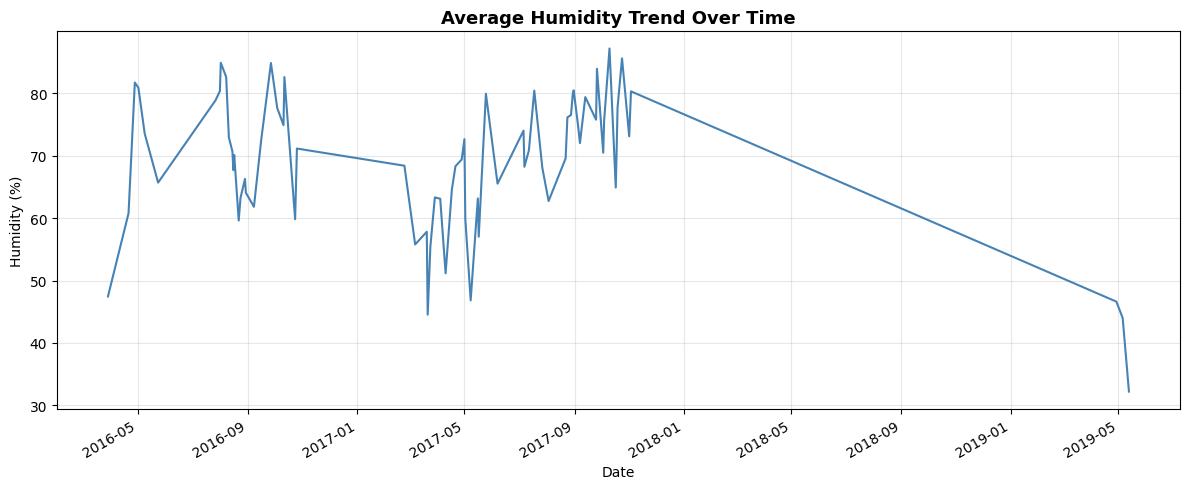

In [ ]:
hw_ts = hourly_weather.copy()
hw_ts['Date'] = pd.to_datetime(hw_ts['Date'], errors='coerce')
hw_ts['Humidity'] = pd.to_numeric(hw_ts['Humidity'], errors='coerce')
weather_trend = hw_ts.groupby('Date')['Humidity'].mean()

plt.figure(figsize=(12, 5))
weather_trend.plot(color='steelblue', linewidth=1.5)
plt.title('Average Humidity Trend Over Time', fontsize=13, fontweight='bold')
plt.xlabel('Date')
plt.ylabel('Humidity (%)')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.8 Pattern Analysis Using Pairplot

#### This helped us to detect hidden relationships between hive features. It identifies clusters of healthy colonies and stressed colony patterns.

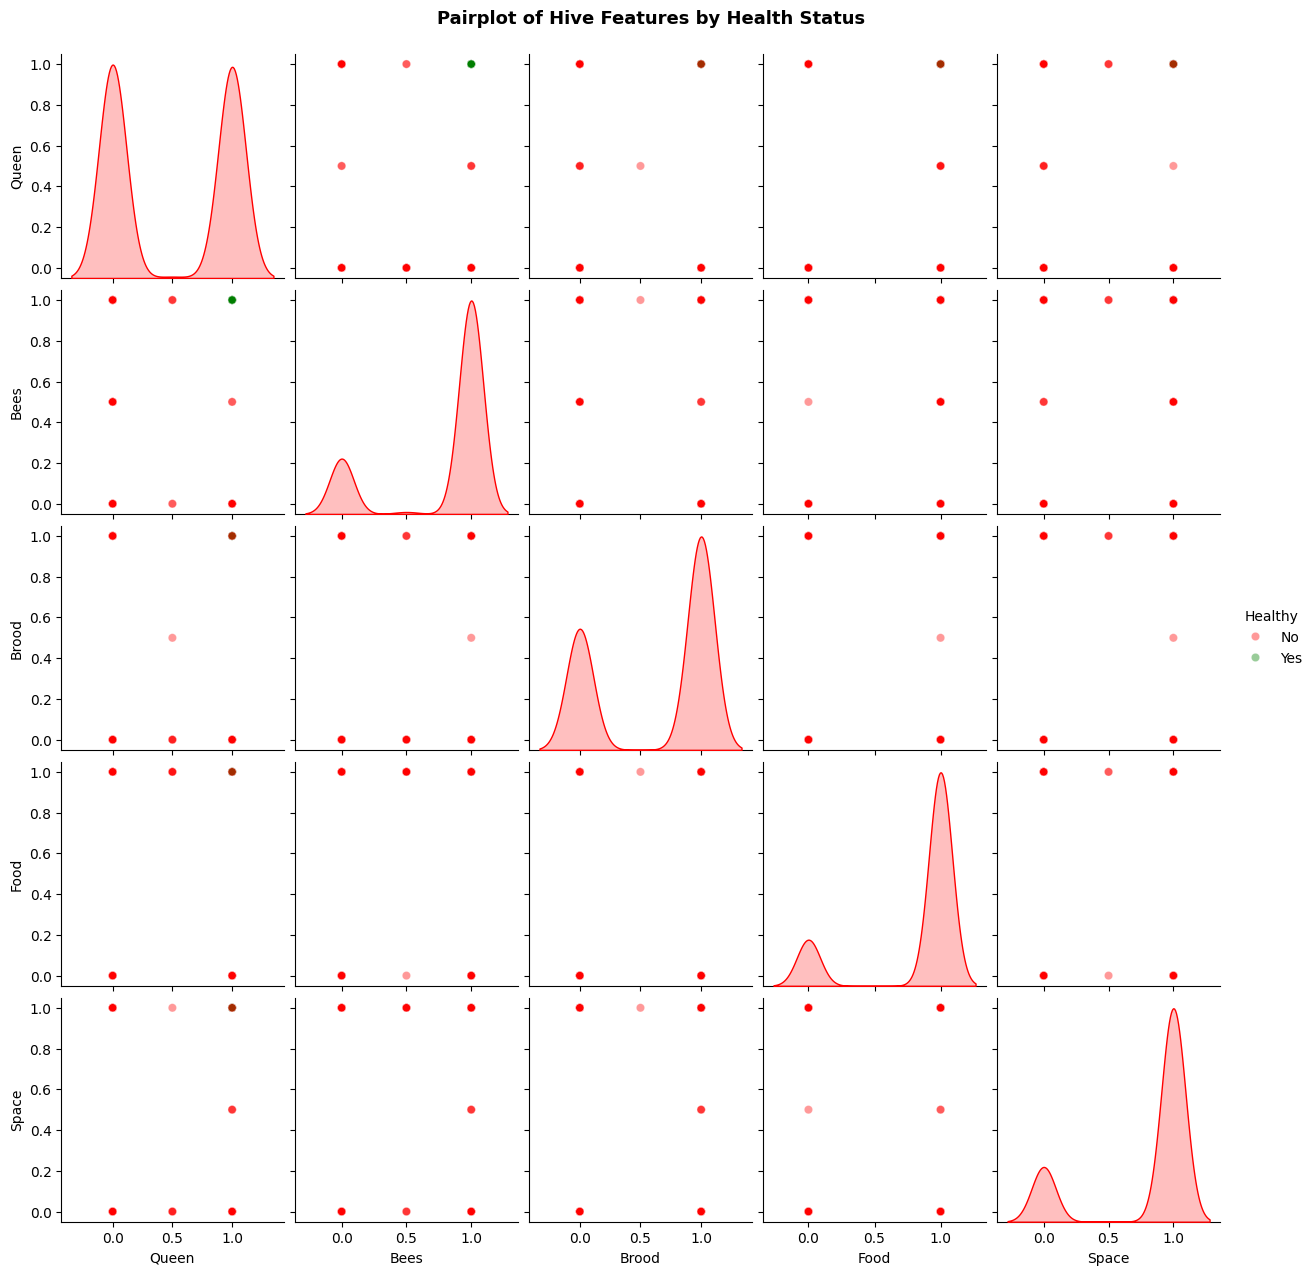

In [ ]:
pairplot_data = inspections[['Queen', 'Bees', 'Brood', 'Food', 'Space', 'Healthy']].dropna()
sns.pairplot(pairplot_data, hue='Healthy', palette={'Yes': 'green', 'No': 'red'}, plot_kws={'alpha': 0.4})
plt.suptitle('Pairplot of Hive Features by Health Status', y=1.02, fontsize=13, fontweight='bold')
plt.show()

### 11.9 Feature Importance Insight for Pre-ML Pattern Discovery

#### Even before training models, we can estimate important features using a Random Forest classifier. This plot shows which inspection factors most influence hive health.

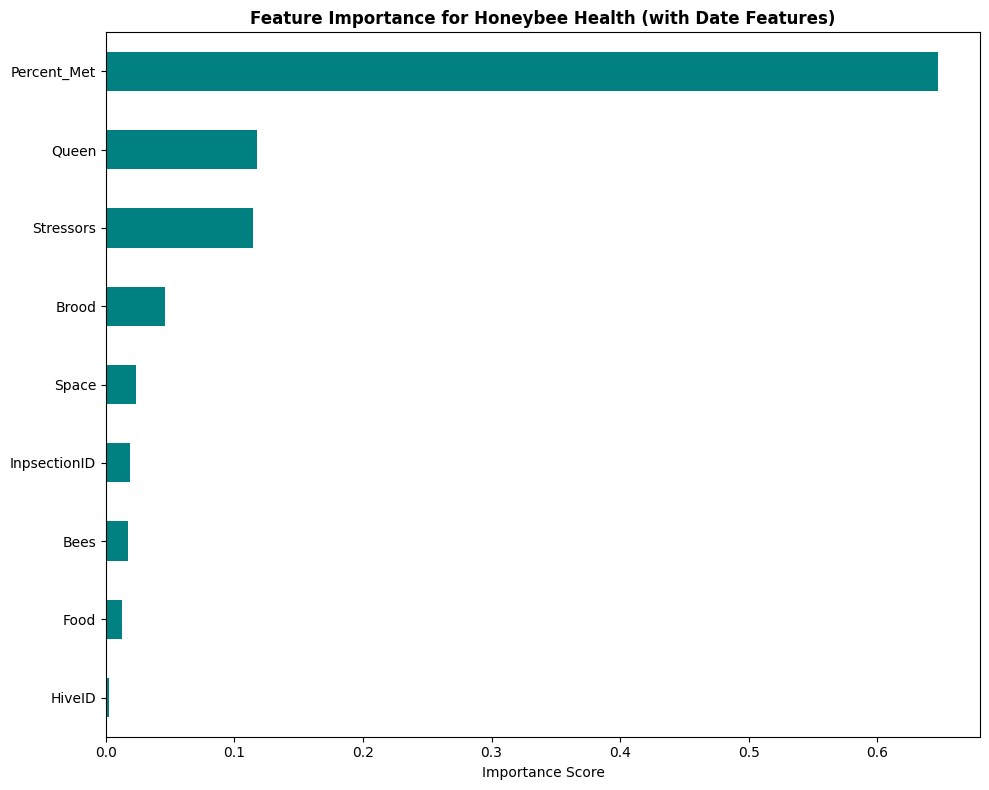

In [ ]:
fi_insp = inspections.copy()
fi_insp['InsptDate'] = pd.to_datetime(fi_insp['InsptDate'])
fi_insp['Inspection_Year']      = fi_insp['InsptDate'].dt.year
fi_insp['Inspection_Month']     = fi_insp['InsptDate'].dt.month
fi_insp['Inspection_Day']       = fi_insp['InsptDate'].dt.day
fi_insp['Inspection_DayOfWeek'] = fi_insp['InsptDate'].dt.dayofweek
fi_insp = fi_insp.drop(columns=['InsptDate'], errors='ignore')

# Drop helper columns if added before
fi_insp = fi_insp.drop(columns=['Healthy_encoded', 'Month'], errors='ignore')

X_fi = fi_insp.drop('Healthy', axis=1).select_dtypes(include=['int64', 'float64']).fillna(0)
y_fi_raw = fi_insp['Healthy']

le_fi = LabelEncoder()
y_fi = le_fi.fit_transform(y_fi_raw)

model_fi = RandomForestClassifier(random_state=42)
model_fi.fit(X_fi, y_fi)

importance_fi = pd.Series(model_fi.feature_importances_, index=X_fi.columns)

plt.figure(figsize=(10, 8))
importance_fi.sort_values().plot(kind='barh', color='teal')
plt.title('Feature Importance for Honeybee Health (with Date Features)', fontweight='bold')
plt.xlabel('Importance Score')
plt.tight_layout()
plt.show()

### 11.10 Hive Health vs Weather Interaction Plot

#### This interaction plot explores the relationship between environmental variables and colony health. It helps us to identify environmental conditions that might contribute to colony stress.

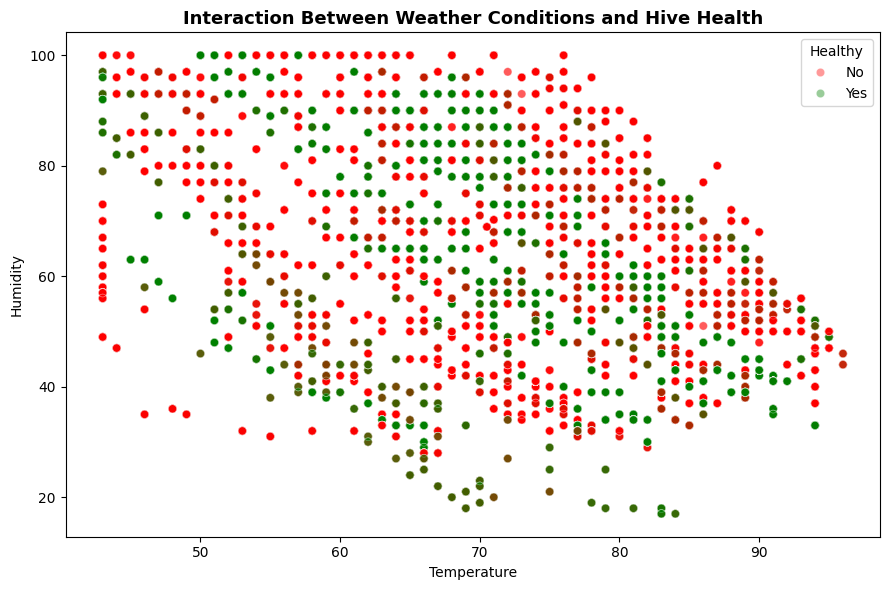

In [ ]:
plt.figure(figsize=(9, 6))
sns.scatterplot(
    data=final_dataset,
    x='Temperature',
    y='Humidity',
    hue='Healthy',
    alpha=0.4,
    palette={'Yes': 'green', 'No': 'red'}
)
plt.title('Interaction Between Weather Conditions and Hive Health', fontsize=13, fontweight='bold')
plt.xlabel('Temperature')
plt.ylabel('Humidity')
plt.legend(title='Healthy')
plt.tight_layout()
plt.show()

### 11.11 Colony Stress Detection Using Clustering

#### Clustering helps to detect hidden colony condition groups without using labels. Here, we are using K-Means Clustering.

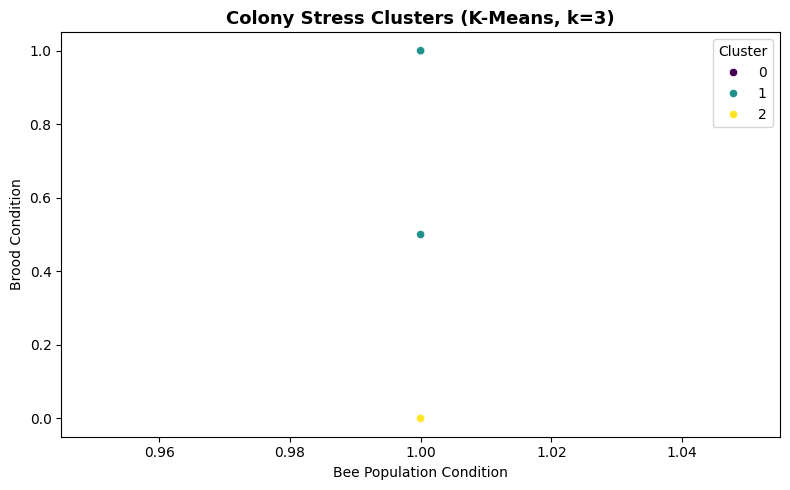

In [ ]:
# Use final_dataset for clustering
features_for_clustering_cols = ['Queen', 'Bees', 'Brood', 'Food', 'Space']

# Drop NaN rows in clustering features only
cleaned_fd = final_dataset.dropna(subset=features_for_clustering_cols).copy()
features_cluster = cleaned_fd[features_for_clustering_cols]

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
cleaned_fd['Cluster'] = kmeans.fit_predict(features_cluster)
final_dataset['Cluster'] = np.nan
final_dataset.loc[cleaned_fd.index, 'Cluster'] = cleaned_fd['Cluster']

plt.figure(figsize=(8, 5))
sns.scatterplot(
    x=cleaned_fd['Bees'],
    y=cleaned_fd['Brood'],
    hue=cleaned_fd['Cluster'],
    palette='viridis'
)
plt.title('Colony Stress Clusters (K-Means, k=3)', fontsize=13, fontweight='bold')
plt.xlabel('Bee Population Condition')
plt.ylabel('Brood Condition')
plt.tight_layout()
plt.show()

# **Interpretation of Cluster**
- Cluster 0 is Healthy colonies
- Cluster 1 is Moderately stressed colonies
- Cluster 2 is Highly stressed colonies

Clustering analysis was used to group colonies based on inspection conditions, by helping to identify stressed colonies even before classification models were applied.

### 11.12 Seasonal Honeybee Survival Analysis

#### Bee colony health commonly depends on seasonal changes. We have observed lower health in winter months and higher health during spring nectar flow.

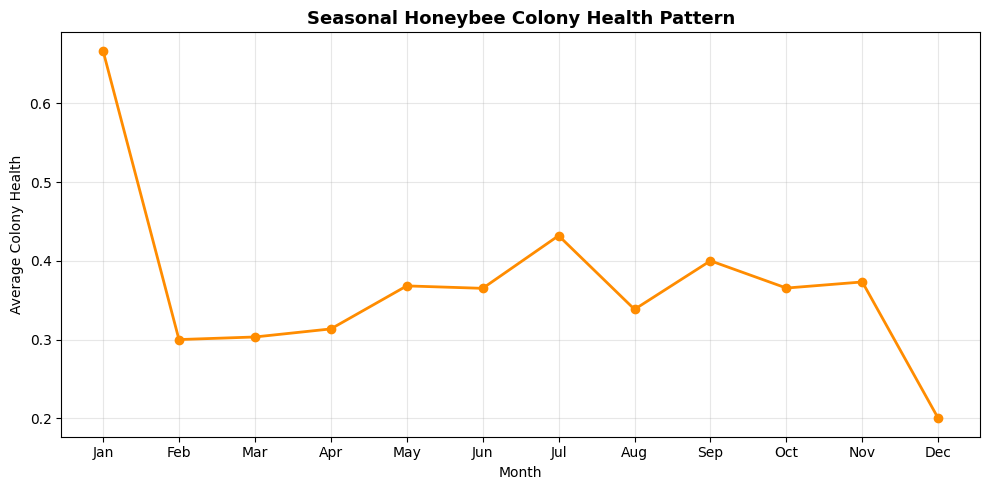

In [ ]:
insp_monthly = inspections.copy()
insp_monthly['InsptDate'] = pd.to_datetime(insp_monthly['InsptDate'])
insp_monthly['Month'] = insp_monthly['InsptDate'].dt.month
le_mon = LabelEncoder()
insp_monthly['Healthy_encoded'] = le_mon.fit_transform(insp_monthly['Healthy'])
monthly_health = insp_monthly.groupby('Month')['Healthy_encoded'].mean()

month_names = {1:'Jan',2:'Feb',3:'Mar',4:'Apr',5:'May',6:'Jun',
               7:'Jul',8:'Aug',9:'Sep',10:'Oct',11:'Nov',12:'Dec'}

plt.figure(figsize=(10, 5))
monthly_health.plot(marker='o', color='darkorange', linewidth=2)
plt.xticks(ticks=monthly_health.index,
           labels=[month_names.get(m, str(m)) for m in monthly_health.index])
plt.title('Seasonal Honeybee Colony Health Pattern', fontsize=13, fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Colony Health')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.13 Colony Health Distribution on Final Integrated Dataset

It is showing the class distribution after all preprocessing steps are complete.

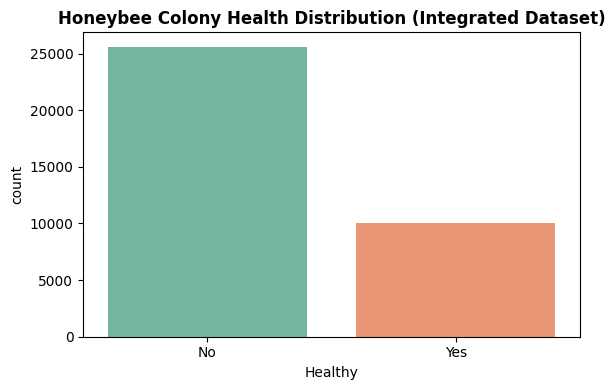

In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Healthy', data=final_dataset, palette='Set2')
plt.title('Honeybee Colony Health Distribution (Integrated Dataset)', fontweight='bold')
plt.tight_layout()
plt.show()

### 11.14 Seasonal Health Trend on Final Integrated Dataset

#### Seasonal analysis was done on the fully integrated and feature-engineered dataset.

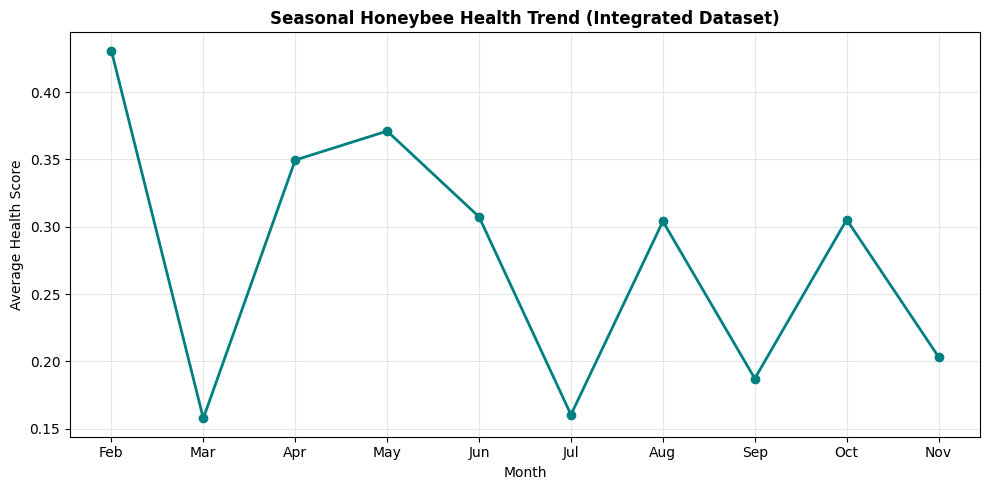

In [ ]:
final_dataset['Month'] = final_dataset['Date'].dt.month
monthly_fd = final_dataset.groupby('Month')['Healthy_encoded'].mean()

plt.figure(figsize=(10, 5))
monthly_fd.plot(marker='o', color='teal', linewidth=2)
plt.xticks(ticks=monthly_fd.index,
           labels=[month_names.get(int(m), str(m)) for m in monthly_fd.index
                   if not pd.isna(m)])
plt.title('Seasonal Honeybee Health Trend (Integrated Dataset)', fontweight='bold')
plt.xlabel('Month')
plt.ylabel('Average Health Score')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 11.15 Hive Stress Index vs Colony Health (Visualizing the Engineered Features)

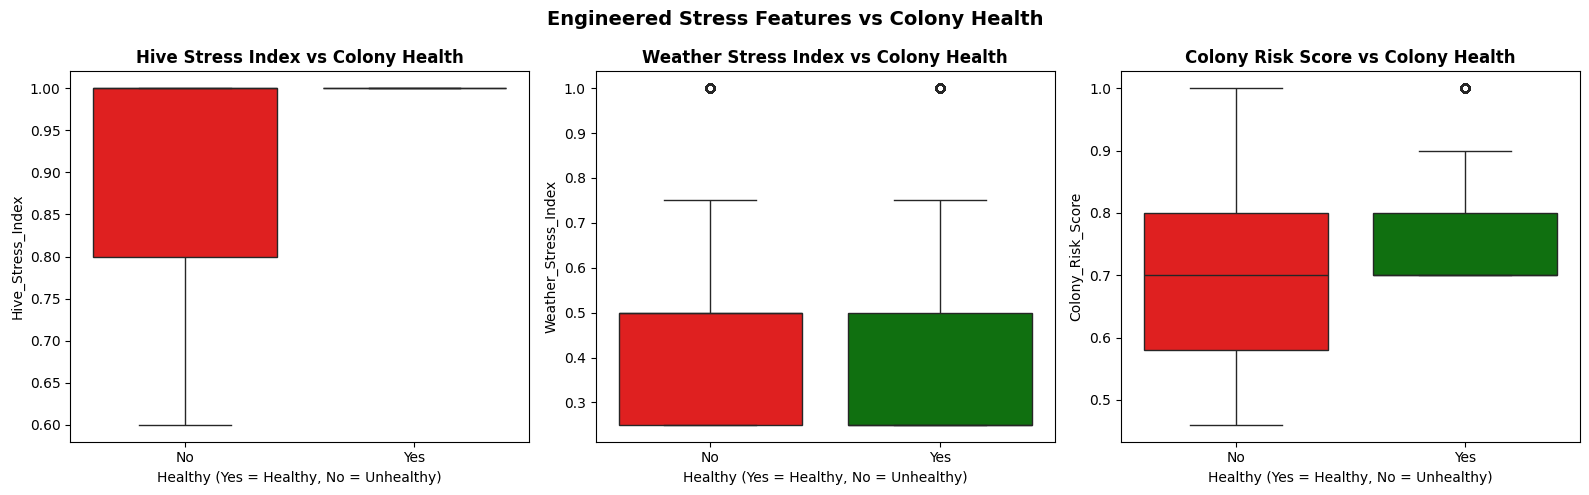

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

sns.boxplot(x='Healthy', y='Hive_Stress_Index', data=final_dataset,
            palette={'Yes': 'green', 'No': 'red'}, ax=axes[0])
axes[0].set_title('Hive Stress Index vs Colony Health', fontweight='bold')
axes[0].set_xlabel('Healthy (Yes = Healthy, No = Unhealthy)')

sns.boxplot(x='Healthy', y='Weather_Stress_Index', data=final_dataset,
            palette={'Yes': 'green', 'No': 'red'}, ax=axes[1])
axes[1].set_title('Weather Stress Index vs Colony Health', fontweight='bold')
axes[1].set_xlabel('Healthy (Yes = Healthy, No = Unhealthy)')

sns.boxplot(x='Healthy', y='Colony_Risk_Score', data=final_dataset,
            palette={'Yes': 'green', 'No': 'red'}, ax=axes[2])
axes[2].set_title('Colony Risk Score vs Colony Health', fontweight='bold')
axes[2].set_xlabel('Healthy (Yes = Healthy, No = Unhealthy)')

plt.suptitle('Engineered Stress Features vs Colony Health', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# **Visual Summary**

Data visualization has revealed patterns in hive inspections and weather conditions. The correlation heatmap has highlighted relationships between inspection parameters and colony health. Trend analysis has helped to identify temporal patterns whereas weather analysis had explored environmental impacts on honeybee colonies. Clustering and seasonal analysis have further uncovered hidden structure.

# **The List of Visualizations We Have Covered Till Now:-**
1. Missing values heatmap
2. Hive health distribution
3. Inspection feature distributions for 6 features
4. Correlation heatmap for inspection features
5. Correlation heatmap for full integrated dataset
6. Temperature vs hive health
7. Hive health trend over time
8. Humidity trend over time
9. Pairplot for inspection features
10. Feature importance using Random Forest
11. Hive health vs weather interaction plot
12. Colony stress clusters using K-Means
13. Seasonal survival analysis
14. Colony health distribution for integrated dataset
15. Engineered features vs colony health
Preprocessing Stages covered till here are:-
```
Data Integration > Data Cleaning > Data Transformation > Data Reduction > Feature Engineering > Data Visualization  >Pattern Analysis
```

## 12. Feature Encoding

#### Now, we are going to encode the categorical variables. Categorical variables have to be converted to numerical form before applying machine learning algorithms.

In [ ]:
# FEATURE ENCODING
label = LabelEncoder()

# Encode all object columns (excluding date and bin columns)
skip_cols = ['InsptDate', 'Date', 'Obs_Time', 'Sunrise', 'Sunset',
             'Daylight_Hours', 'Temp_Bin', 'Temp_Bins', 'Temp_Freq_Bins']

for col in final_dataset.select_dtypes(include='object').columns:
    if col not in skip_cols:
        try:
            final_dataset[col] = label.fit_transform(final_dataset[col].astype(str))
        except Exception as e:
            print(f'Skipped encoding {col}: {e}')

print('Encoding complete. Remaining object columns:')
print(final_dataset.select_dtypes(include='object').columns.tolist())

Encoding complete. Remaining object columns:
['Sunrise', 'Sunset', 'Daylight_Hours', 'Obs_Time']


## 13. Data Normalization

#### Now, we are scaling numerical features. Weather attributes have different scales like Temperature is −10 to 40, Humidity is 0 to 100, Pressure is 950 to 1050. Min-Max Scaling normalizes all values to the range [0, 1].

# **Formula**

# X' = (X − X_min) / (X_max − X_min)

In [ ]:
# NORMALIZATION
scaler = MinMaxScaler()

# Scale only numeric columns; skip date columns
num_cols = final_dataset.select_dtypes(include=['int64', 'float64', 'int32']).columns
final_dataset[num_cols] = scaler.fit_transform(final_dataset[num_cols])

print('Normalization complete.')
print('Feature ranges after scaling (min / max):')
print(final_dataset[num_cols].describe().loc[['min', 'max']].to_string())

Normalization complete.
Feature ranges after scaling (min / max):
     InpsectionID  HiveID  Brood  Bees  Queen  Food  Stressors  Space  Percent_Met  Healthy  Hive_Tag  ApiaryID  Apiary  City  State  WeatherID  ObsID  StationID  Temperature  Humidity  Dew_Point  Wind_Direction  Wind_Speed  Wind_Gust  Pressure  Precip  Condition  Station_City  Station  Obs_Hour  Temp_Smoothed  Temp_RollingAvg  Temperature_Smoothed  Humidity_Smoothed  Wind_Speed_Smoothed  Pressure_Smoothed  Day  Temp_Mean  Temp_Min  Temp_Max  Humidity_Mean  Humidity_Min  Humidity_Max  WindSpeed_Mean  WindSpeed_Max  Pressure_Mean  Precip_Total  Hive_Stress_Index  Temp_Stress  Humidity_Stress  Wind_Stress  Rain_Stress  Weather_Stress_Index  Colony_Risk_Score  Temp_Range  Healthy_encoded  Cluster  Month
min           0.0     0.0    0.0   0.0    0.0   0.0        0.0    0.0          0.0      0.0       0.0       0.0     0.0   0.0    0.0        0.0    0.0        0.0          0.0       0.0        0.0             0.0         0.0 

## 14. Outlier Detection for Post-Normalization Check

#### We are using the IQR method in our project. After normalization, we are doing a final check to confirm that any remaining outliers have been addressed.

In [ ]:
# OUTLIER DETECTION (IQR) — Final Check
# Select only numerical columns for quantile calculation
numeric_final_dataset = final_dataset.select_dtypes(include=['number'])

Q1 = numeric_final_dataset.quantile(0.25)
Q3 = numeric_final_dataset.quantile(0.75)
IQR = Q3 - Q1

outlier_check = ((numeric_final_dataset < (Q1 - 1.5 * IQR)) |
                 (numeric_final_dataset > (Q3 + 1.5 * IQR)))

print('Outlier counts per column after normalization (numerical columns only):')
print(outlier_check.sum().sort_values(ascending=False).head(15))
print(f'\nFinal Clean Dataset Size: {final_dataset.shape}')
print('(Rows x Columns)')

Outlier counts per column after normalization (numerical columns only):
Cluster                 9696
City                    5026
Precip_Total            4349
Rain_Stress             4349
State                   3650
Pressure_Mean           2465
Apiary                  1220
Humidity_Max            1126
Station                  624
Temperature              604
Wind_Stress              604
Weather_Stress_Index     604
WindSpeed_Max            604
Temp_RollingAvg          569
Dew_Point                408
dtype: int64

Final Clean Dataset Size: (35656, 67)
(Rows x Columns)


In [ ]:
print('Final Clean Dataset — First 5 Rows:')
print(final_dataset.head())

Final Clean Dataset — First 5 Rows:
   InpsectionID  HiveID  InsptDate  Brood  Bees  Queen  Food  Stressors  \
0      0.000000     0.0 2016-06-15    1.0   0.0    1.0   0.0        0.0   
1      0.000416     0.0 2016-07-22    1.0   0.0    1.0   0.0        0.0   
2      0.000832     0.0 2016-08-01    1.0   0.0    1.0   0.0        1.0   
3      0.000832     0.0 2016-08-01    1.0   0.0    1.0   0.0        1.0   
4      0.000832     0.0 2016-08-01    1.0   0.0    1.0   0.0        1.0   

   Space  Percent_Met  ...  Temp_Stress  Humidity_Stress  Wind_Stress  \
0    0.0     0.793939  ...          0.0              1.0          0.0   
1    0.0     0.793939  ...          0.0              1.0          0.0   
2    0.0     1.000000  ...          0.0              1.0          0.0   
3    0.0     1.000000  ...          0.0              1.0          0.0   
4    0.0     1.000000  ...          0.0              1.0          0.0   

   Rain_Stress  Weather_Stress_Index  Colony_Risk_Score  Temp_Range  \
0  

## 15. Extracting Independent and Dependent Variables

### After we have finished data integration and our combined dataset is stored in final_dataset, the next step before modeling is to separate
- **Independent variables (features)** i.e. X
- **Dependent variable (target/label)** i.e. y

## In our honeybee dataset, the target variable is the hive health indicator which is the column Healthy.

In [ ]:
# Target variable (Dependent Variable)
y = final_dataset['Healthy']

# Feature variables (Independent Variables)
X = final_dataset.drop('Healthy', axis=1)

print('Shape of X (features):', X.shape)
print('Shape of y (target):', y.shape)

Shape of X (features): (35656, 66)
Shape of y (target): (35656,)


# **Explanation**
- y contains the target variable representing whether the colony is healthy or not.
- X contains all other features, including hive inspection attributes and weather variables.
- This type of separation is required before applying machine learning algorithms.
## So, it is recommended to remove non-predictive identifiers such as ID and date columns from features.

In [ ]:
# Remove non-predictive identifiers from features
X = final_dataset.drop(
    ['Healthy', 'Date', 'InsptDate', 'Day', 'HiveID', 'ApiaryID',
     'Temp_Bin', 'Temp_Bins', 'Temp_Freq_Bins'],
    axis=1,
    errors='ignore'
)
y = final_dataset['Healthy']

print('Shape of X after removing identifiers:', X.shape)
print('Shape of y:', y.shape)

print('\nX — first 5 rows:')
print(X.head())
print('\ny — first 5 values:')
print(y.head())

Shape of X after removing identifiers: (35656, 58)
Shape of y: (35656,)

X — first 5 rows:
   InpsectionID  Brood  Bees  Queen  Food  Stressors  Space  Percent_Met  \
0      0.000000    1.0   0.0    1.0   0.0        0.0    0.0     0.793939   
1      0.000416    1.0   0.0    1.0   0.0        0.0    0.0     0.793939   
2      0.000832    1.0   0.0    1.0   0.0        1.0    0.0     1.000000   
3      0.000832    1.0   0.0    1.0   0.0        1.0    0.0     1.000000   
4      0.000832    1.0   0.0    1.0   0.0        1.0    0.0     1.000000   

   Hive_Tag  Apiary  ...  Temp_Stress  Humidity_Stress  Wind_Stress  \
0  0.342466     0.0  ...          0.0              1.0          0.0   
1  0.342466     0.0  ...          0.0              1.0          0.0   
2  0.342466     0.0  ...          0.0              1.0          0.0   
3  0.342466     0.0  ...          0.0              1.0          0.0   
4  0.342466     0.0  ...          0.0              1.0          0.0   

   Rain_Stress  Weather_S

## Here the dataset is divided into independent variables X and the dependent variable y. The target variable represents the health status of the honeybee colony, while the remaining attributes act as predictors for analysis and model training i.e. the independent variables.

## 16. Data Reduction

### PCA + Feature Selection is the best selection for Data Reduction options here.
### For our honeybee dataset, the approach we have used is:-
- **Feature Selection** = to choose the most relevant variables for prediction.
- **PCA (Principal Component Analysis)** = to reduce dimensionality of numerical features.

# **Order of Steps**
```
Feature Aggregation > Feature Engineering > Feature Selection > PCA > Train/Test Split > Modeling
```

### 16.1 Preparing X and y (Numeric only for Feature Selection & PCA)

In [ ]:
# Target variable
y = final_dataset['Healthy']

# Remove non-predictive / ID / date columns
X = final_dataset.drop(
    ['Healthy', 'Date', 'InsptDate', 'Day', 'HiveID', 'ApiaryID',
     'Temp_Bin', 'Temp_Bins', 'Temp_Freq_Bins'],
    axis=1,
    errors='ignore'
)

# Keep only numeric features for feature selection and PCA
X_numeric = X.select_dtypes(include=['int64', 'float64'])

print('X shape:', X_numeric.shape)
print('y shape:', y.shape)

X shape: (35656, 54)
y shape: (35656,)


### 16.2 Correlation-Based Feature Selection

#### This works on numeric features so that we can select features with |correlation| > 0.05 with the target.

In [ ]:
# Combine X and y for correlation analysis
feature_data = X_numeric.copy()
feature_data['Healthy'] = y.values

numeric_feature_data = feature_data.select_dtypes(include=['int64', 'float64'])

# Correlation with target
target_corr = numeric_feature_data.corr()['Healthy'].drop('Healthy').sort_values(
    key=abs, ascending=False
)

print('Feature correlation with Healthy:')
print(target_corr.to_string())

Feature correlation with Healthy:
Healthy_encoded         1.000000e+00
Percent_Met             6.646322e-01
Stressors               6.399116e-01
Hive_Stress_Index       4.262491e-01
Apiary                  3.882711e-01
Brood                   3.830272e-01
Queen                   3.669157e-01
InpsectionID            3.436116e-01
Colony_Risk_Score       3.433970e-01
Hive_Tag               -3.092374e-01
State                   2.688802e-01
Wind_Stress             1.331468e-01
City                    1.274780e-01
ObsID                  -1.061333e-01
Precip_Total            1.039121e-01
Humidity_Min           -1.004465e-01
Cluster                -8.794828e-02
Humidity_Mean          -8.659901e-02
Wind_Direction         -6.884589e-02
Station                 6.465900e-02
Rain_Stress             5.781923e-02
Temp_Range              5.367234e-02
Month                  -4.986088e-02
Pressure_Mean          -4.820029e-02
Humidity_Max           -4.630915e-02
Humidity               -4.561195e-02
Dew_

In [ ]:
selected_corr_features = target_corr[abs(target_corr) > 0.05].index.tolist()

print(f'Features selected by correlation (|corr| > 0.05): {len(selected_corr_features)}')
print(selected_corr_features)

Features selected by correlation (|corr| > 0.05): 22
['Healthy_encoded', 'Percent_Met', 'Stressors', 'Hive_Stress_Index', 'Apiary', 'Brood', 'Queen', 'InpsectionID', 'Colony_Risk_Score', 'Hive_Tag', 'State', 'Wind_Stress', 'City', 'ObsID', 'Precip_Total', 'Humidity_Min', 'Cluster', 'Humidity_Mean', 'Wind_Direction', 'Station', 'Rain_Stress', 'Temp_Range']


### 16.3 Random Forest (Feature Importance)

In [ ]:
# Keep only numeric columns for model-based feature importance
X_numeric_clean = X_numeric.fillna(0)

rf = RandomForestClassifier(random_state=42)
rf.fit(X_numeric_clean, y)

feature_importance = pd.Series(
    rf.feature_importances_,
    index=X_numeric_clean.columns
).sort_values(ascending=False)

print('Random Forest Feature Importance:')
print(feature_importance.to_string())

Random Forest Feature Importance:
Percent_Met             3.641603e-01
Healthy_encoded         3.041361e-01
Stressors               1.290621e-01
Hive_Stress_Index       4.151342e-02
Colony_Risk_Score       2.983348e-02
Hive_Tag                2.739959e-02
InpsectionID            1.969823e-02
Brood                   1.652352e-02
Queen                   1.292360e-02
Apiary                  1.137357e-02
State                   8.127283e-03
City                    6.311035e-03
ObsID                   4.219477e-03
Month                   2.498841e-03
Pressure                1.945574e-03
Cluster                 1.908469e-03
Humidity_Mean           1.814984e-03
WindSpeed_Max           1.654051e-03
WindSpeed_Mean          1.577026e-03
Temp_Range              1.555594e-03
WeatherID               1.516728e-03
Temp_Min                1.426778e-03
Humidity_Min            1.217889e-03
Temp_Mean               1.162216e-03
Precip_Total            1.160799e-03
Temp_Max                1.090018e-03
Humi

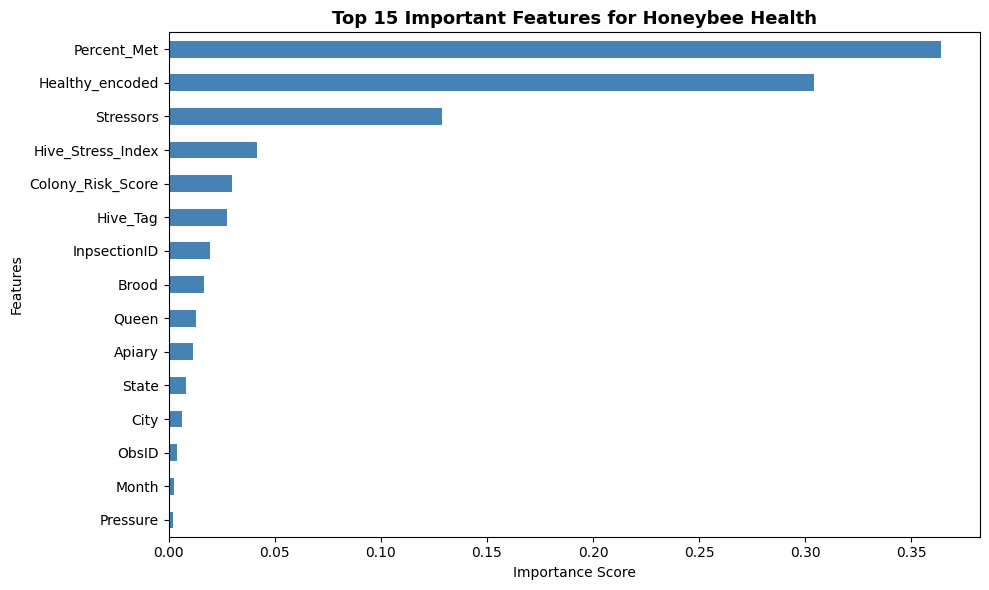

In [ ]:
plt.figure(figsize=(10, 6))
feature_importance.head(15).sort_values().plot(kind='barh', color='steelblue')
plt.title('Top 15 Important Features for Honeybee Health', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Features')
plt.tight_layout()
plt.show()

In [ ]:
# Select Top N features
top_n = 10
selected_rf_features = feature_importance.head(top_n).index.tolist()

print('Top features selected using Random Forest:')
print(selected_rf_features)

X_selected = X_numeric_clean[selected_rf_features]
print('\nShape after feature selection:', X_selected.shape)
print(X_selected.head())

Top features selected using Random Forest:
['Percent_Met', 'Healthy_encoded', 'Stressors', 'Hive_Stress_Index', 'Colony_Risk_Score', 'Hive_Tag', 'InpsectionID', 'Brood', 'Queen', 'Apiary']

Shape after feature selection: (35656, 10)
   Percent_Met  Healthy_encoded  Stressors  Hive_Stress_Index  \
0     0.793939              0.0        0.0                1.0   
1     0.793939              0.0        0.0                1.0   
2     1.000000              1.0        1.0                1.0   
3     1.000000              1.0        1.0                1.0   
4     1.000000              1.0        1.0                1.0   

   Colony_Risk_Score  Hive_Tag  InpsectionID  Brood  Queen  Apiary  
0            0.62963  0.342466      0.000000    1.0    1.0     0.0  
1            0.62963  0.342466      0.000416    1.0    1.0     0.0  
2            0.62963  0.342466      0.000832    1.0    1.0     0.0  
3            0.62963  0.342466      0.000832    1.0    1.0     0.0  
4            0.62963  0.342466 

### 16.4 SelectKBest (Statistical Feature Selection)

#### Here, we are using ANOVA F-score because our target is a classification problem. This is mainly used to refer to a statistical feature selection technique.

In [ ]:
# Impute any remaining NaN before SelectKBest
imputer = SimpleImputer(strategy='mean')
X_imputed = imputer.fit_transform(X_numeric_clean)

k = min(10, X_numeric_clean.shape[1])  # ensure k <= number of features
selector = SelectKBest(score_func=f_classif, k=k)
X_kbest = selector.fit_transform(X_imputed, y)

selected_kbest_features = X_numeric_clean.columns[selector.get_support()].tolist()

print(f'Top {k} features selected using SelectKBest (ANOVA F-score):')
print(selected_kbest_features)

Top 10 features selected using SelectKBest (ANOVA F-score):
['InpsectionID', 'Brood', 'Queen', 'Stressors', 'Percent_Met', 'Hive_Tag', 'Apiary', 'Hive_Stress_Index', 'Colony_Risk_Score', 'Healthy_encoded']


### 16.5 PCA (Dimensionality Reduction)

#### We have applied Principal Component Analysis. PCA should be applied only to numerical features, and it works best after standardization (StandardScaler is better than MinMax for PCA).

#### Step A - Standardize Before PCA

In [ ]:
scaler_pca = StandardScaler()
X_scaled = scaler_pca.fit_transform(X_numeric_clean)

#### Step B - Fit PCA and Check Explained Variance

In [ ]:
pca = PCA()
X_pca_all = pca.fit_transform(X_scaled)

explained_variance = pca.explained_variance_ratio_
cumulative_variance = np.cumsum(explained_variance)

print('Explained variance ratio:')
print(explained_variance)

print('\nCumulative explained variance:')
print(cumulative_variance)

Explained variance ratio:
[1.74135175e-01 1.30702678e-01 1.07486543e-01 8.98309616e-02
 7.11885615e-02 5.79363706e-02 4.87468329e-02 3.95456102e-02
 3.77182353e-02 2.97700403e-02 2.19025200e-02 2.04054760e-02
 1.96046700e-02 1.86586075e-02 1.76034331e-02 1.60467929e-02
 1.37854259e-02 1.16998027e-02 1.15097842e-02 8.50768666e-03
 7.78759272e-03 6.49076935e-03 5.39110059e-03 5.29473962e-03
 4.32213417e-03 3.93606406e-03 3.81100744e-03 2.81864971e-03
 2.50649119e-03 2.14276232e-03 1.65158440e-03 1.44732021e-03
 1.34779415e-03 1.10948626e-03 7.15540434e-04 6.16916704e-04
 5.71823845e-04 4.56313358e-04 2.80831322e-04 2.35762875e-04
 1.33599832e-04 7.93777817e-05 6.71303438e-05 7.40509862e-17
 3.58529759e-17 1.63247121e-17 6.60961706e-18 1.05122465e-18
 1.70159232e-33 0.00000000e+00 0.00000000e+00 0.00000000e+00
 0.00000000e+00 0.00000000e+00]

Cumulative explained variance:
[0.17413518 0.30483785 0.4123244  0.50215536 0.57334392 0.63128029
 0.68002712 0.71957273 0.75729097 0.78706101 0.808

#### Step C - Plot Explained Variance

##### We choose the number of components that explains 90% variance (common choice) or 95% variance (more conservative).

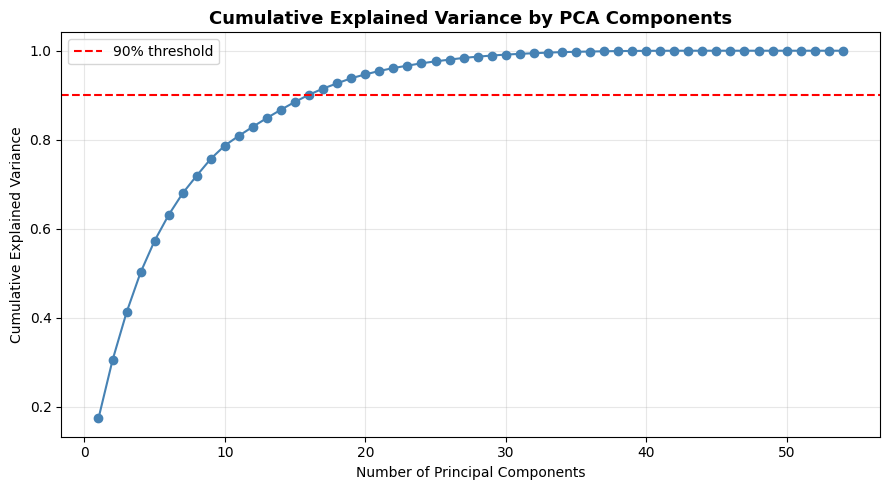

In [ ]:
plt.figure(figsize=(9, 5))
plt.plot(range(1, len(cumulative_variance) + 1), cumulative_variance, marker='o', color='steelblue')
plt.axhline(y=0.90, linestyle='--', color='red', label='90% threshold')
plt.title('Cumulative Explained Variance by PCA Components', fontsize=13, fontweight='bold')
plt.xlabel('Number of Principal Components')
plt.ylabel('Cumulative Explained Variance')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Step D - Selecting Number of PCA Components Automatically

In [ ]:
# Find minimum number of components to retain 90% variance
n_components_90 = int(np.argmax(cumulative_variance >= 0.90)) + 1

print('Number of components for 90% variance:', n_components_90)

Number of components for 90% variance: 16


#### Step E - Transform Data Using Selected PCA Components

In [ ]:
pca_final = PCA(n_components=n_components_90)
X_pca = pca_final.fit_transform(X_scaled)

print('Shape after PCA:', X_pca.shape)
print('\nNow X_pca is our reduced feature space.')

Shape after PCA: (35656, 16)

Now X_pca is our reduced feature space.


### PCA Loadings - Interpreting Component Contributions

#### This helps us to interpret which original features contribute most to the principal components.

In [ ]:
pca_loadings = pd.DataFrame(
    pca_final.components_.T,
    columns=[f'PC{i+1}' for i in range(n_components_90)],
    index=X_numeric_clean.columns
)

print('PCA Loadings:')
print(pca_loadings.to_string())

PCA Loadings:
                               PC1           PC2           PC3           PC4           PC5           PC6           PC7           PC8           PC9          PC10          PC11          PC12          PC13          PC14          PC15          PC16
InpsectionID         -2.478954e-02  1.085196e-02  2.051085e-01 -5.098090e-02  2.124740e-01  3.278569e-01  5.559287e-02 -7.354424e-02  1.722977e-01 -1.852027e-01 -2.474793e-01  1.390049e-02  1.212311e-01 -7.942568e-02 -2.231406e-01 -7.791986e-03
Brood                 5.881502e-02 -9.642623e-02  2.745311e-01 -1.611286e-01 -9.324736e-02 -1.575488e-01  5.644374e-03  9.829216e-05  4.308985e-03  8.041017e-02 -2.192576e-02  1.114106e-01  9.731652e-02  3.705346e-01  7.262670e-02 -3.309380e-01
Bees                  2.220446e-16  5.551115e-17 -2.220446e-16  1.387779e-17  1.110223e-16  1.665335e-16 -9.714451e-17  1.387779e-16  1.110223e-16  2.775558e-17  1.110223e-16 -2.081668e-17 -8.326673e-17  3.330669e-16  2.498002e-16 -2.610759e-16
Queen 

### 16.6 Practically Logical Choice of Features

In [ ]:
print('X_selected — Feature Selection result:')
print(X_selected.shape)
print(X_selected.head())

X_selected — Feature Selection result:
(35656, 10)
   Percent_Met  Healthy_encoded  Stressors  Hive_Stress_Index  \
0     0.793939              0.0        0.0                1.0   
1     0.793939              0.0        0.0                1.0   
2     1.000000              1.0        1.0                1.0   
3     1.000000              1.0        1.0                1.0   
4     1.000000              1.0        1.0                1.0   

   Colony_Risk_Score  Hive_Tag  InpsectionID  Brood  Queen  Apiary  
0            0.62963  0.342466      0.000000    1.0    1.0     0.0  
1            0.62963  0.342466      0.000416    1.0    1.0     0.0  
2            0.62963  0.342466      0.000832    1.0    1.0     0.0  
3            0.62963  0.342466      0.000832    1.0    1.0     0.0  
4            0.62963  0.342466      0.000832    1.0    1.0     0.0  


In [ ]:
print('X_pca — PCA result:')
print(X_pca.shape)

X_pca — PCA result:
(35656, 16)


# 17. Key Findings from data preprocessing:-

- Hive inspection parameters such as queen condition and brood health strongly influence colony status.
- Weather conditions such as temperature and humidity have shown potential relationships with hive health.
- Dataset required integration of 6 separate relational tables.
- Preprocessing has ensured high data quality for modeling.
- Feature aggregation was very important to meaningfully combine hourly weather with periodic hive inspections.
- Clustering has revealed distinct groups of healthy and stressed colonies.
- Seasonal analysis suggested environmental effects on colony health across months.
- PCA has reduced the weather feature space while at the same time retaining 90% of variance.

## 18. Preprocessing Pipeline Flowchart

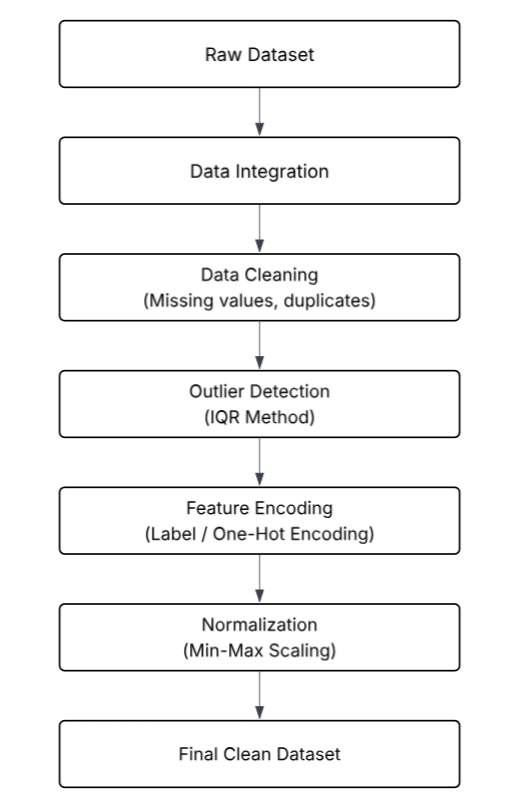

# **Data Reduction Explanation**

## Data reduction was performed using both feature selection and Principal Component Analysis (PCA). Feature selection was applied to identify the most relevant predictors of honeybee colony health using correlation analysis and Random Forest feature importance. This has improved interpretability by retaining the most meaningful hive and weather variables.

## To sum up, PCA was additionally used as a dimensionality reduction technique on standardized numerical features. The number of principal components was selected based on cumulative explained variance, retaining approximately 90% of the total variance. This has reduced redundancy among weather and engineered features while preserving most of the information in the dataset.

## For data reduction, feature selection was primarily used because it preserved interpretability, which is very important for understanding which hive and weather variables influence colony health. PCA was also applied as an optional dimensionality reduction method to reduce redundancy among numerical features while retaining most of the variance.

## So, for our final pipeline we will be using:-
- X_selected for our main machine learning models
- X_pca as a comparison experiment

In [ ]:
# Retrieving the final dataset
final_dataset.to_csv('cleaned_dataset.csv', index=False)

## 19. Data Modelling

### In this phase we will train, evaluate, and compare multiple classification models to determine which one will best predict honeybee colony health.

# **Important design decisions made here are:**
- We will work at the **inspection level** (2,404 rows) using daily-aggregated weather features. This will avoid data leakage that would occur if we modelled on the row-exploded merged dataset where each inspection repeats approx 15 times.
- "Percent_Met" is **excluded** because it is directly derived from the health label (Percent_Met = 100 if and only if Healthy = Yes) so it is a pure leakage.
- "Healthy_encoded", "InpsectionID", "HiveID", "ApiaryID", "WeatherID", "ObsID", "StationID" are excluded as they are identifiers which are not predictive features.

**Models that we trained are:-**
1. Logistic Regression
2. Decision Tree
3. Random Forest
4. Gradient Boosting
5. K-Nearest Neighbors (KNN)
6. Naive Bayes
7. AdaBoost

**Evaluation metrics that we used are:-**
- Accuracy
- Precision
- Recall
- F1-Score
- ROC-AUC

### 19.1 Building Inspection-Level Modelling Dataset

#### We have constructed a clean, inspection-level dataset (one row per inspection) by merging daily-aggregated weather with hive inspection records and adding engineered features.

In [ ]:
# Step 1: Rebuild inspection-level dataset for modelling

# Re-load raw data to avoid any state from preprocessing steps above
insp_mod = pd.read_csv("HCC_Inspections.csv")
hive_mod = pd.read_csv("Hive_Information.csv")
apiary_mod = pd.read_csv("Apiary_Information.csv")
hw_mod = pd.read_csv("Hourly_Weather.csv")
ws_mod = pd.read_csv("Weather_Stations.csv")
wo_mod = pd.read_csv("Weather_Observations.csv")

# Clean
insp_mod.fillna(insp_mod.mode().iloc[0], inplace=True)
insp_mod.drop_duplicates(inplace=True)
hive_mod['Hive_Tag'].fillna('Unknown', inplace=True)

for col in ['Temperature','Humidity','Wind_Speed','Pressure','Precip']:
    if col in hw_mod.columns:
        hw_mod[col] = pd.to_numeric(
            hw_mod[col].astype(str).str.replace(r'[^0-9.-]', '', regex=True),
            errors='coerce'
        )
        hw_mod[col].fillna(hw_mod[col].mean(), inplace=True)

# Merge hive + apiary
hive_apiary_mod = pd.merge(hive_mod, apiary_mod, on='ApiaryID', how='left')
hive_full_mod = pd.merge(insp_mod, hive_apiary_mod, on='HiveID', how='left')

# Daily weather aggregates
hw_mod = pd.merge(hw_mod, wo_mod[['ObsID','Date']], on='ObsID', how='left')
hw_mod['Date'] = pd.to_datetime(hw_mod['Date'], errors='coerce')
hw_mod['Day'] = hw_mod['Date'].dt.date

daily_weather_mod = hw_mod.groupby('Day').agg(
    Temp_Mean=('Temperature','mean'),
    Temp_Min=('Temperature','min'),
    Temp_Max=('Temperature','max'),
    Humidity_Mean=('Humidity','mean'),
    Humidity_Min=('Humidity','min'),
    Humidity_Max=('Humidity','max'),
    WindSpeed_Mean=('Wind_Speed','mean'),
    WindSpeed_Max=('Wind_Speed','max'),
    Pressure_Mean=('Pressure','mean'),
    Precip_Total=('Precip','sum')
).reset_index()

# Merge weather into inspections
hive_full_mod['InsptDate'] = pd.to_datetime(hive_full_mod['InsptDate'])
hive_full_mod['Day'] = hive_full_mod['InsptDate'].dt.date
model_df = pd.merge(hive_full_mod, daily_weather_mod, on='Day', how='left')

# Feature Engineering
model_df['Hive_Stress_Index'] = (
    model_df['Queen'].fillna(0) + model_df['Bees'].fillna(0) +
    model_df['Brood'].fillna(0) + model_df['Food'].fillna(0) +
    model_df['Space'].fillna(0)
) / 5

model_df['Temp_Stress']     = np.where((model_df['Temp_Mean']<15)|(model_df['Temp_Mean']>30),1,0)
model_df['Humidity_Stress'] = np.where((model_df['Humidity_Mean']<40)|(model_df['Humidity_Mean']>70),1,0)
model_df['Wind_Stress']     = np.where(model_df['WindSpeed_Mean']>15,1,0)
model_df['Rain_Stress']     = np.where(model_df['Precip_Total']>0,1,0)
model_df['Weather_Stress_Index'] = (
    model_df['Temp_Stress'] + model_df['Humidity_Stress'] +
    model_df['Wind_Stress'] + model_df['Rain_Stress']
) / 4
model_df['Colony_Risk_Score'] = (
    0.6 * model_df['Hive_Stress_Index'] +
    0.4 * model_df['Weather_Stress_Index']
)
model_df['Temp_Range']          = model_df['Temp_Max'] - model_df['Temp_Min']
model_df['Inspection_Month']    = model_df['InsptDate'].dt.month
model_df['Inspection_Year']     = model_df['InsptDate'].dt.year
model_df['Inspection_DayOfWeek']= model_df['InsptDate'].dt.dayofweek

# Encode categorical location features
le_enc = LabelEncoder()
model_df['State_enc']  = le_enc.fit_transform(model_df['State'].astype(str))
model_df['City_enc']   = le_enc.fit_transform(model_df['City'].astype(str))
model_df['Apiary_enc'] = le_enc.fit_transform(model_df['Apiary'].astype(str))

# Define feature columns (no leakage, no IDs)
FEATURE_COLS = [
    'Brood', 'Bees', 'Queen', 'Food', 'Stressors', 'Space',
    'Temp_Mean', 'Temp_Min', 'Temp_Max',
    'Humidity_Mean', 'Humidity_Min', 'Humidity_Max',
    'WindSpeed_Mean', 'WindSpeed_Max',
    'Pressure_Mean', 'Precip_Total',
    'Hive_Stress_Index', 'Weather_Stress_Index',
    'Colony_Risk_Score', 'Temp_Range',
    'Inspection_Month', 'Inspection_Year', 'Inspection_DayOfWeek',
    'State_enc', 'City_enc', 'Apiary_enc'
]

X_model = model_df[FEATURE_COLS].fillna(0)

# Target: encode Healthy (Yes=1, No=0)
le_target = LabelEncoder()
y_model = le_target.fit_transform(model_df['Healthy'].astype(str))

# Scale features
scaler_model = MinMaxScaler()
X_model_scaled = pd.DataFrame(
    scaler_model.fit_transform(X_model),
    columns=FEATURE_COLS
)

print(f"Modelling dataset shape: {X_model_scaled.shape}")
print(f"Target distribution:")
print(f"  Healthy (1): {(y_model==1).sum()} ({(y_model==1).mean()*100:.1f}%)")
print(f"  Unhealthy (0): {(y_model==0).sum()} ({(y_model==0).mean()*100:.1f}%)")
print(f"\nFeatures used ({len(FEATURE_COLS)}):")
print(FEATURE_COLS)

Modelling dataset shape: (2404, 26)
Target distribution:
  Healthy (1): 873 (36.3%)
  Unhealthy (0): 1531 (63.7%)

Features used (26):
['Brood', 'Bees', 'Queen', 'Food', 'Stressors', 'Space', 'Temp_Mean', 'Temp_Min', 'Temp_Max', 'Humidity_Mean', 'Humidity_Min', 'Humidity_Max', 'WindSpeed_Mean', 'WindSpeed_Max', 'Pressure_Mean', 'Precip_Total', 'Hive_Stress_Index', 'Weather_Stress_Index', 'Colony_Risk_Score', 'Temp_Range', 'Inspection_Month', 'Inspection_Year', 'Inspection_DayOfWeek', 'State_enc', 'City_enc', 'Apiary_enc']


### 19.2 Train/Test Split

#### We split the data into 80% training and 20% testing using stratified sampling to maintain the class distribution in both sets.

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
    X_model_scaled, y_model,
    test_size=0.2,
    random_state=42,
    stratify=y_model
)

print(f"Training set : {X_train.shape[0]} samples")
print(f"Testing set  : {X_test.shape[0]} samples")
print(f"\nTraining class distribution:")
print(f"  Healthy (1): {(y_train==1).sum()}  |  Unhealthy (0): {(y_train==0).sum()}")
print(f"\nTesting class distribution:")
print(f"  Healthy (1): {(y_test==1).sum()}  |  Unhealthy (0): {(y_test==0).sum()}")

Training set : 1923 samples
Testing set  : 481 samples

Training class distribution:
  Healthy (1): 698  |  Unhealthy (0): 1225

Testing class distribution:
  Healthy (1): 175  |  Unhealthy (0): 306


### 19.3 Handling Class Imbalance using SMOTE

#### The training set had a class imbalance of about 36% healthy vs 64% unhealthy colonies. Training a model on imbalanced data can cause it to be biased toward the majority class.

#### We have used **SMOTE (Synthetic Minority Oversampling Technique)** to generate synthetic samples for the minority class (healthy = 1) in the training set only. The test set is left untouched to show the real-world class distribution.

In [ ]:
sm = SMOTE(random_state=42)
X_train_sm, y_train_sm = sm.fit_resample(X_train, y_train)

print(f"Before SMOTE — Train class distribution:")
print(f"  Healthy (1): {(y_train==1).sum()}  |  Unhealthy (0): {(y_train==0).sum()}")
print(f"\nAfter SMOTE  — Train class distribution:")
print(f"  Healthy (1): {(y_train_sm==1).sum()}  |  Unhealthy (0): {(y_train_sm==0).sum()}")
print(f"\nNew training set size: {X_train_sm.shape[0]} samples")

Before SMOTE — Train class distribution:
  Healthy (1): 698  |  Unhealthy (0): 1225

After SMOTE  — Train class distribution:
  Healthy (1): 1225  |  Unhealthy (0): 1225

New training set size: 2450 samples


### 19.4 Defining All Models

We have defined all 7 classifiers with consistent "random_state=42" for reproducibility.

In [ ]:
all_models = {
    'Logistic Regression' : LogisticRegression(max_iter=1000, random_state=42),
    'Decision Tree'       : DecisionTreeClassifier(max_depth=10, random_state=42),
    'Random Forest'       : RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1),
    'Gradient Boosting'   : GradientBoostingClassifier(n_estimators=100, random_state=42),
    'K-Nearest Neighbors' : KNeighborsClassifier(n_neighbors=5),
    'Naive Bayes'         : GaussianNB(),
    'AdaBoost'            : AdaBoostClassifier(n_estimators=100, random_state=42),
}

print(f"Total models to evaluate: {len(all_models)}")
for name in all_models:
    print(f"  - {name}")

Total models to evaluate: 7
  - Logistic Regression
  - Decision Tree
  - Random Forest
  - Gradient Boosting
  - K-Nearest Neighbors
  - Naive Bayes
  - AdaBoost


### 19.5 Training All Models and Evaluating Performance

In [ ]:
results = {}
trained_models = {}

print("Training and evaluating all models...\n")

for name, model in all_models.items():
    # Train
    model.fit(X_train_sm, y_train_sm)
    trained_models[name] = model

    # Predict
    y_pred  = model.predict(X_test)
    y_proba = model.predict_proba(X_test)[:, 1]

    # Metrics
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, zero_division=0)
    rec  = recall_score(y_test, y_pred, zero_division=0)
    f1   = f1_score(y_test, y_pred, zero_division=0)
    roc  = roc_auc_score(y_test, y_proba)

    results[name] = {
        'Accuracy' : round(acc, 4),
        'Precision': round(prec, 4),
        'Recall'   : round(rec, 4),
        'F1-Score' : round(f1, 4),
        'ROC-AUC'  : round(roc, 4)
    }

    print(f"{name}")
    print(f"  Accuracy={acc:.4f}  Precision={prec:.4f}  Recall={rec:.4f}  F1={f1:.4f}  AUC={roc:.4f}")
    print()

Training and evaluating all models...

Logistic Regression
  Accuracy=0.9979  Precision=0.9943  Recall=1.0000  F1=0.9972  AUC=0.9990

Decision Tree
  Accuracy=0.9979  Precision=0.9943  Recall=1.0000  F1=0.9972  AUC=0.9984

Random Forest
  Accuracy=0.9979  Precision=0.9943  Recall=1.0000  F1=0.9972  AUC=0.9981

Gradient Boosting
  Accuracy=0.9979  Precision=0.9943  Recall=1.0000  F1=0.9972  AUC=0.9995

K-Nearest Neighbors
  Accuracy=0.9958  Precision=0.9887  Recall=1.0000  F1=0.9943  AUC=0.9983

Naive Bayes
  Accuracy=0.9979  Precision=0.9943  Recall=1.0000  F1=0.9972  AUC=0.9984

AdaBoost
  Accuracy=0.9958  Precision=0.9943  Recall=0.9943  F1=0.9943  AUC=0.9995



### 19.5.1 Decision Tree Visualization

Decision Tree — Text Rules (depth limited to 3 for readability):
|--- Hive_Stress_Index <= 0.95
|   |--- class: 0
|--- Hive_Stress_Index >  0.95
|   |--- Stressors <= 0.75
|   |   |--- class: 0
|   |--- Stressors >  0.75
|   |   |--- Inspection_Month <= 0.89
|   |   |   |--- Inspection_Year <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Inspection_Year >  0.50
|   |   |   |   |--- truncated branch of depth 6
|   |   |--- Inspection_Month >  0.89
|   |   |   |--- Inspection_Year <= 0.50
|   |   |   |   |--- class: 1
|   |   |   |--- Inspection_Year >  0.50
|   |   |   |   |--- truncated branch of depth 6



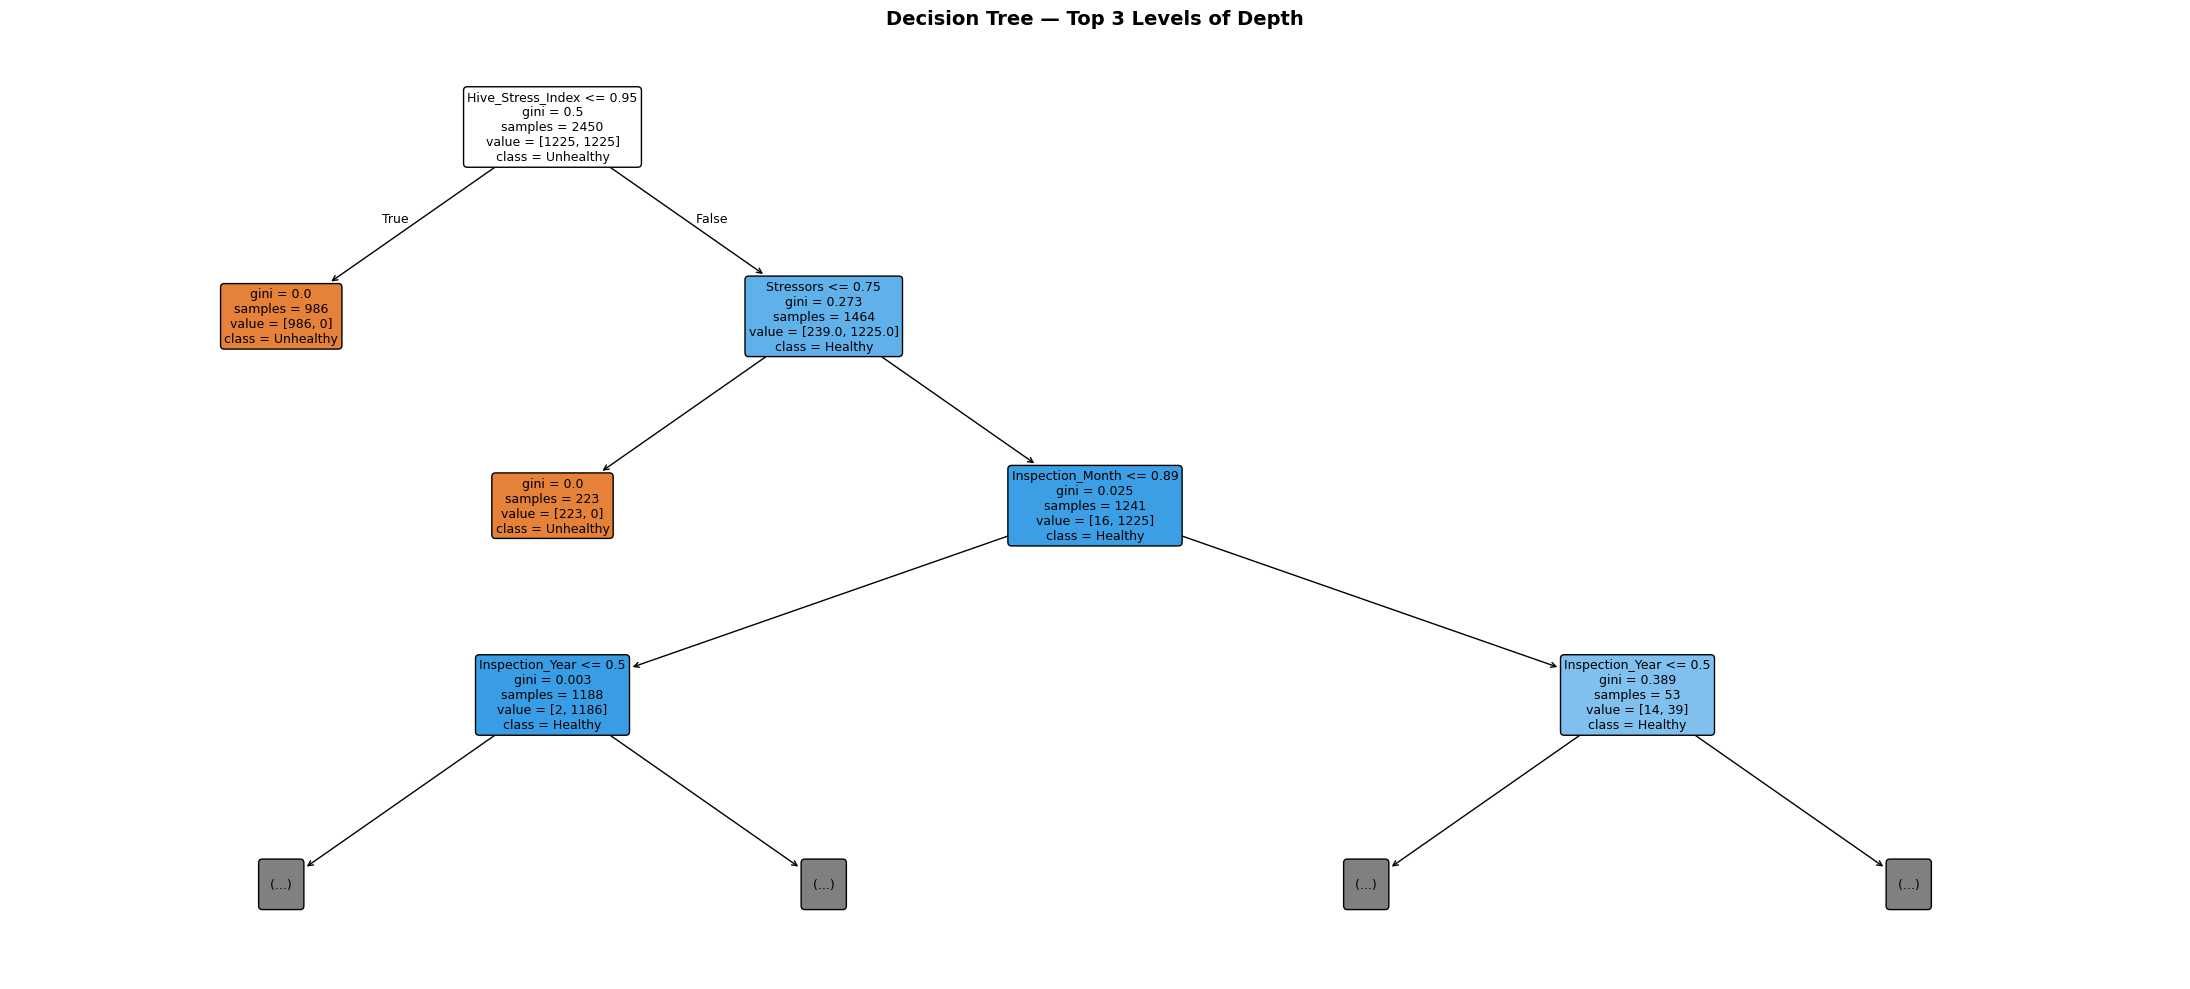

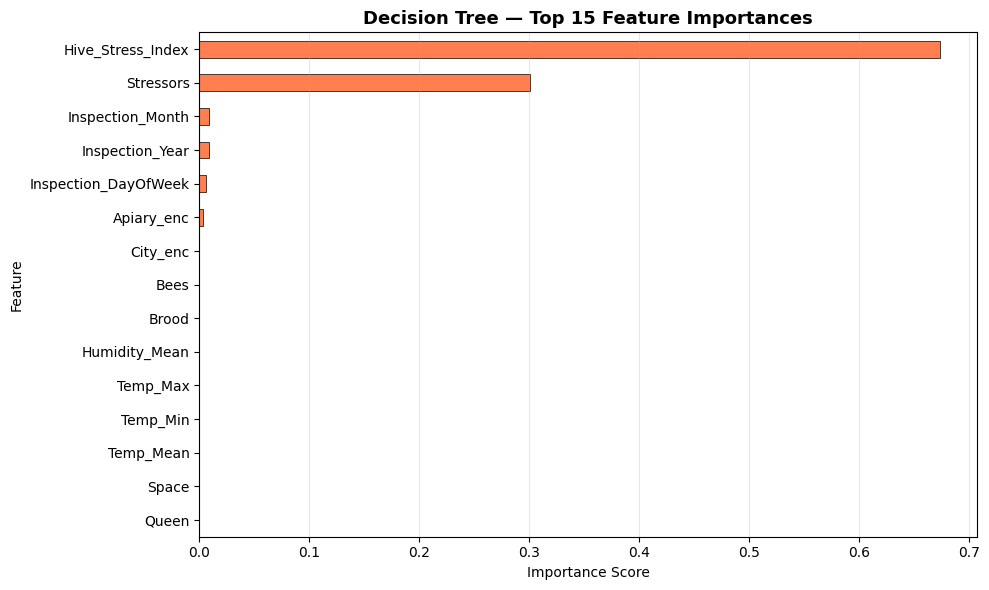


Top 10 Features by Decision Tree Importance:
Hive_Stress_Index       0.673497
Stressors               0.300717
Inspection_Month        0.008635
Inspection_Year         0.008518
Inspection_DayOfWeek    0.005556
Apiary_enc              0.003056
City_enc                0.000020
Queen                   0.000000
Bees                    0.000000
Brood                   0.000000


In [ ]:
from sklearn.tree import plot_tree, export_text

# Get the trained Decision Tree from trained_models
dt_model = trained_models['Decision Tree']

# --- Text Representation ---
print("Decision Tree — Text Rules (depth limited to 3 for readability):")
print(export_text(dt_model, feature_names=FEATURE_COLS, max_depth=3))

# --- Visual Tree Plot ---
plt.figure(figsize=(22, 10))
plot_tree(
    dt_model,
    feature_names=FEATURE_COLS,
    class_names=['Unhealthy', 'Healthy'],
    filled=True,
    rounded=True,
    max_depth=3,       # limit depth so it fits on screen
    fontsize=9,
    impurity=True,
    proportion=False
)
plt.title('Decision Tree — Top 3 Levels of Depth', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# --- Feature Importances from Decision Tree ---
dt_importance = pd.Series(
    dt_model.feature_importances_,
    index=FEATURE_COLS
).sort_values(ascending=False)

plt.figure(figsize=(10, 6))
dt_importance.head(15).sort_values().plot(
    kind='barh', color='coral', edgecolor='black', linewidth=0.5
)
plt.title('Decision Tree — Top 15 Feature Importances', fontsize=13, fontweight='bold')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.grid(axis='x', alpha=0.3)
plt.tight_layout()
plt.show()

print("\nTop 10 Features by Decision Tree Importance:")
print(dt_importance.head(10).to_string())

### 19.6 Model Comparison Table

In [ ]:
results_df = pd.DataFrame(results).T.reset_index()
results_df.columns = ['Model', 'Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
results_df = results_df.sort_values('ROC-AUC', ascending=False).reset_index(drop=True)
results_df.index = results_df.index + 1  # Start ranking from 1

print("=" * 75)
print("MODEL COMPARISON TABLE (sorted by ROC-AUC)")
print("=" * 75)
print(results_df.to_string(index=True))
print("=" * 75)

MODEL COMPARISON TABLE (sorted by ROC-AUC)
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1    Gradient Boosting    0.9979     0.9943  1.0000    0.9972   0.9995
2             AdaBoost    0.9958     0.9943  0.9943    0.9943   0.9995
3  Logistic Regression    0.9979     0.9943  1.0000    0.9972   0.9990
4          Naive Bayes    0.9979     0.9943  1.0000    0.9972   0.9984
5        Decision Tree    0.9979     0.9943  1.0000    0.9972   0.9984
6  K-Nearest Neighbors    0.9958     0.9887  1.0000    0.9943   0.9983
7        Random Forest    0.9979     0.9943  1.0000    0.9972   0.9981


### 19.7 Performance Visualization using Bar Chart Comparison

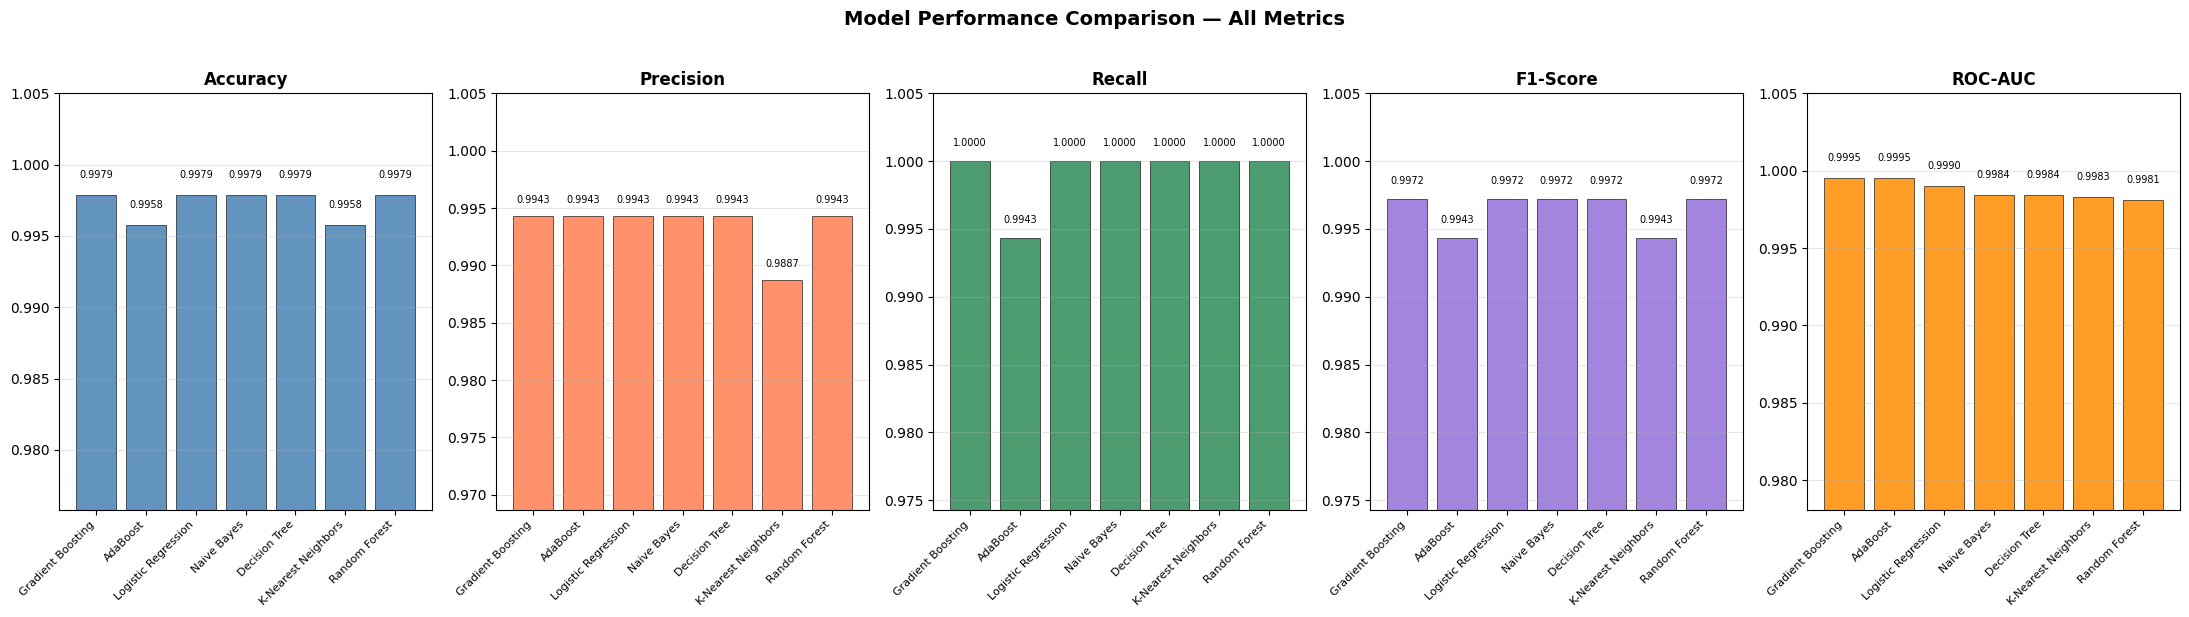

In [ ]:
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score', 'ROC-AUC']
plot_df = results_df.set_index('Model')[metrics]

fig, axes = plt.subplots(1, 5, figsize=(22, 6))

colors = ['steelblue','coral','seagreen','mediumpurple','darkorange']

for ax, metric, color in zip(axes, metrics, colors):
    bars = ax.bar(range(len(plot_df)), plot_df[metric], color=color, alpha=0.85, edgecolor='black', linewidth=0.5)
    ax.set_xticks(range(len(plot_df)))
    ax.set_xticklabels(plot_df.index, rotation=45, ha='right', fontsize=8)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(plot_df[metric].min() - 0.02, 1.005)
    ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f'{x:.3f}'))
    ax.grid(axis='y', alpha=0.3)
    for bar, val in zip(bars, plot_df[metric]):
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                f'{val:.4f}', ha='center', va='bottom', fontsize=7)

plt.suptitle('Model Performance Comparison — All Metrics', fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.show()

### 19.8 Confusion Matrices for All Models

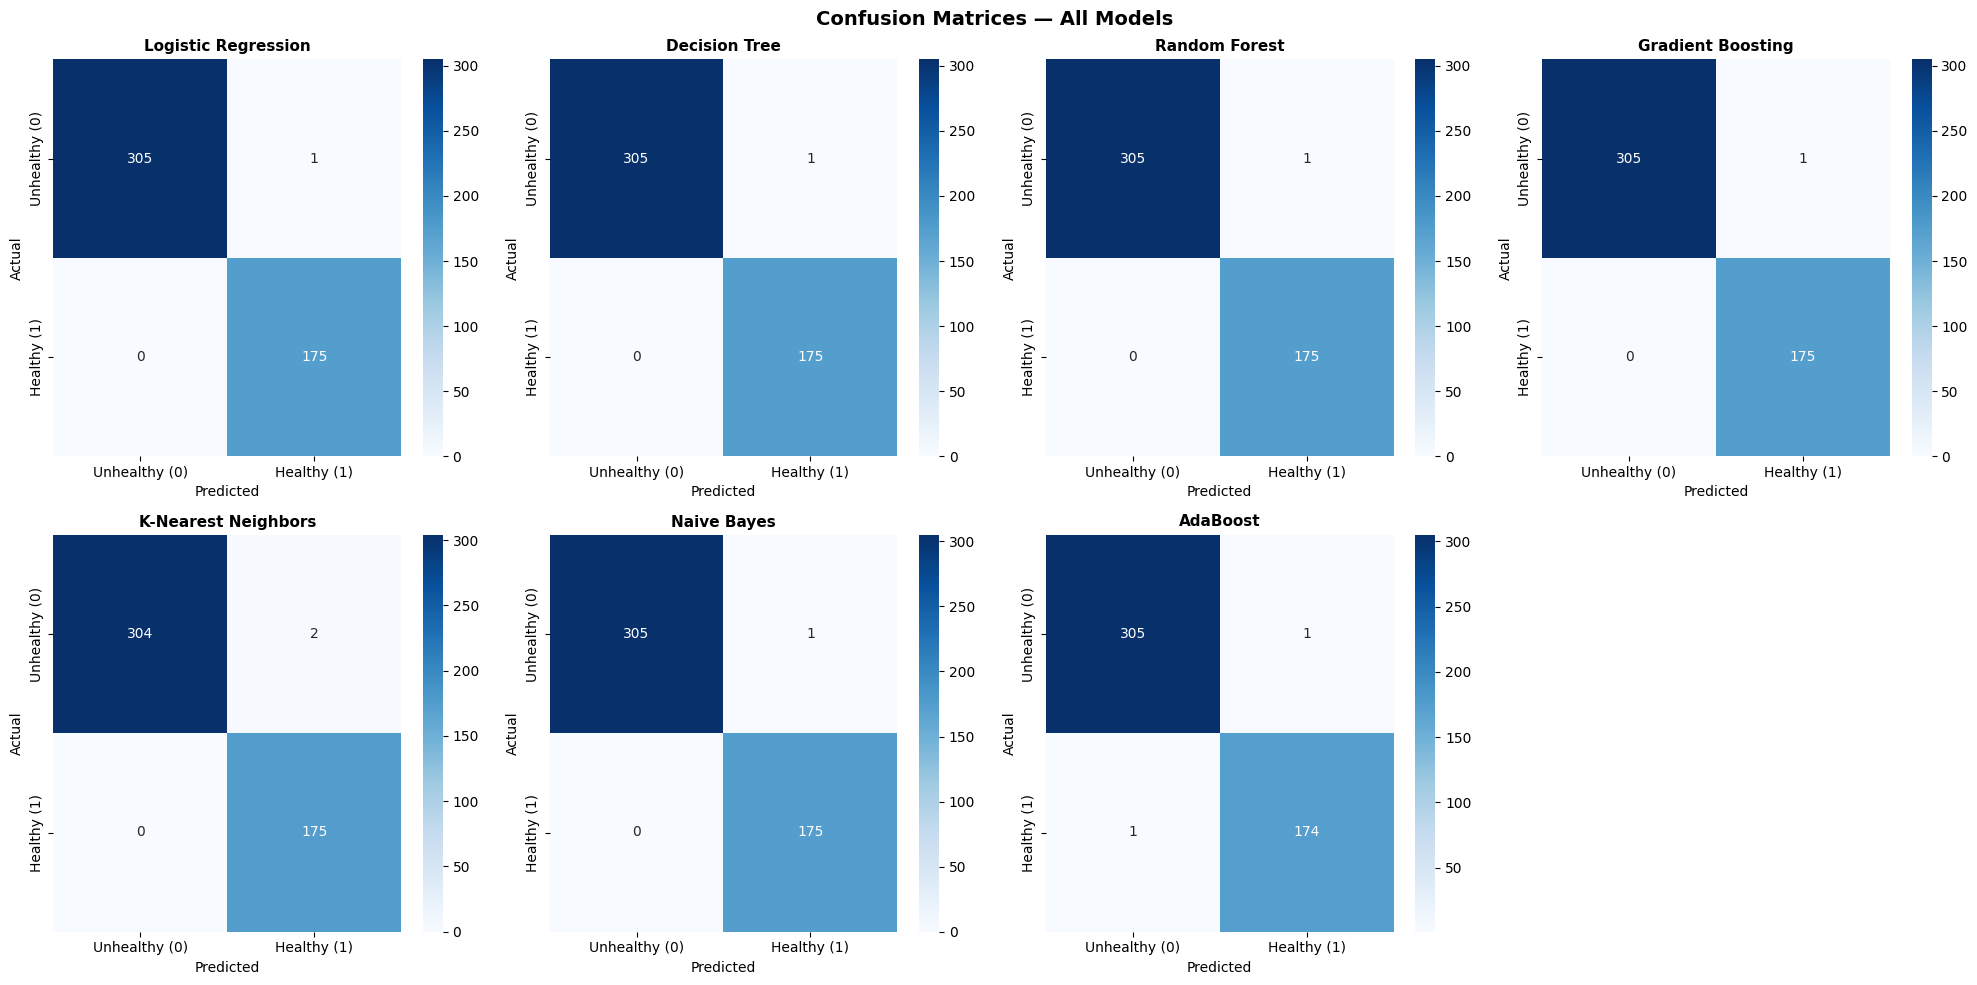

In [ ]:
n_models = len(all_models)
fig, axes = plt.subplots(2, 4, figsize=(20, 10))
axes = axes.flatten()

for i, (name, model) in enumerate(trained_models.items()):
    y_pred = model.predict(X_test)
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=axes[i],
                xticklabels=['Unhealthy (0)', 'Healthy (1)'],
                yticklabels=['Unhealthy (0)', 'Healthy (1)'])
    axes[i].set_title(f'{name}', fontweight='bold', fontsize=11)
    axes[i].set_xlabel('Predicted')
    axes[i].set_ylabel('Actual')

# Hide the extra subplot if models < 8
for j in range(len(trained_models), len(axes)):
    axes[j].set_visible(False)

plt.suptitle('Confusion Matrices — All Models', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

### 19.9 ROC Curves for All Models

## **The ROC (Receiver Operating Characteristic) curve shows the trade-off between True Positive Rate and False Positive Rate at different thresholds. A higher AUC means the model is better at distinguishing healthy from unhealthy colonies.**

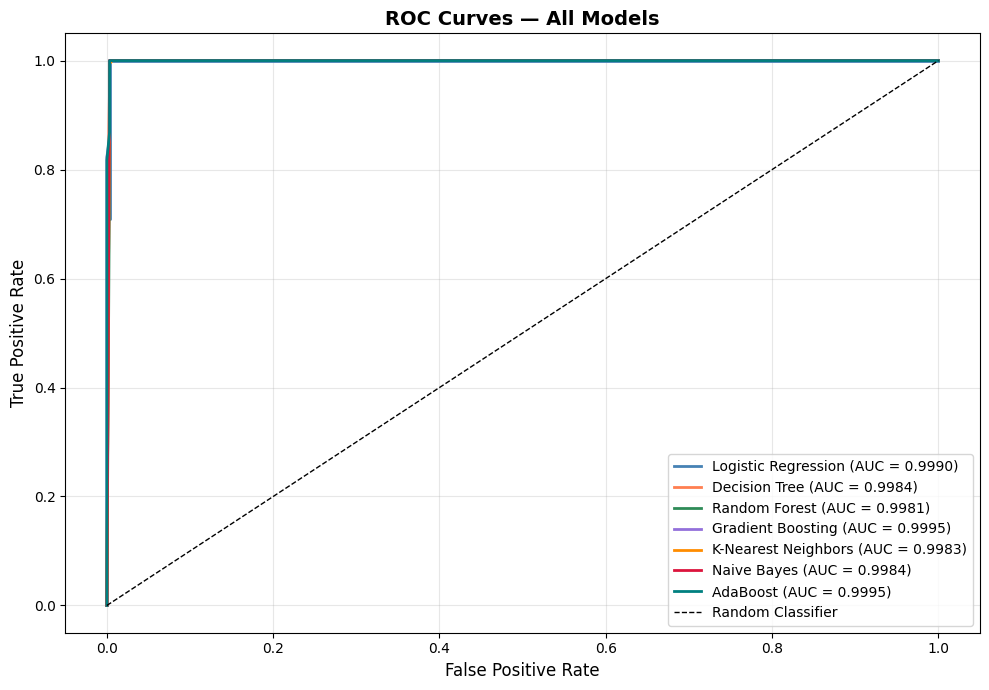

In [ ]:
plt.figure(figsize=(10, 7))

colors_roc = ['steelblue','coral','seagreen','mediumpurple',
              'darkorange','crimson','teal']

for (name, model), color in zip(trained_models.items(), colors_roc):
    y_proba = model.predict_proba(X_test)[:, 1]
    fpr, tpr, _ = roc_curve(y_test, y_proba)
    roc_auc_val = auc(fpr, tpr)
    plt.plot(fpr, tpr, label=f'{name} (AUC = {roc_auc_val:.4f})', color=color, linewidth=2)

plt.plot([0, 1], [0, 1], 'k--', linewidth=1, label='Random Classifier')
plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curves — All Models', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=10)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

### 19.10 Classification Reports for All Models

#### The representation is a detailed precision, recall, and F1-score per class for each model.

In [ ]:
for name, model in trained_models.items():
    y_pred = model.predict(X_test)
    print(f"{'='*60}")
    print(f"  {name}")
    print(f"{'='*60}")
    print(classification_report(
        y_test, y_pred,
        target_names=['Unhealthy (0)', 'Healthy (1)'],
        zero_division=0
    ))

  Logistic Regression
               precision    recall  f1-score   support

Unhealthy (0)       1.00      1.00      1.00       306
  Healthy (1)       0.99      1.00      1.00       175

     accuracy                           1.00       481
    macro avg       1.00      1.00      1.00       481
 weighted avg       1.00      1.00      1.00       481

  Decision Tree
               precision    recall  f1-score   support

Unhealthy (0)       1.00      1.00      1.00       306
  Healthy (1)       0.99      1.00      1.00       175

     accuracy                           1.00       481
    macro avg       1.00      1.00      1.00       481
 weighted avg       1.00      1.00      1.00       481

  Random Forest
               precision    recall  f1-score   support

Unhealthy (0)       1.00      1.00      1.00       306
  Healthy (1)       0.99      1.00      1.00       175

     accuracy                           1.00       481
    macro avg       1.00      1.00      1.00       481
 we

### 19.11 Cross-Validation (5-Fold) on Top Models

#### Cross-validation gives a more reliable estimate of model performance by training and testing on different subsets of the data. We have applied 5-fold stratified cross-validation to the top 3 models.

In [ ]:
top_3 = results_df.head(3)['Model'].tolist()
print("Cross-Validation Results (5-Fold Stratified)\n")
print(f"{'Model':<25} {'Mean Accuracy':>15} {'Std Dev':>10}")
print("-" * 55)

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

for name in top_3:
    model = all_models[name]
    cv_scores = cross_val_score(model, X_model_scaled, y_model,
                                cv=cv, scoring='accuracy', n_jobs=-1)
    print(f"{name:<25} {cv_scores.mean():.4f}          {cv_scores.std():.4f}")

print("\nInterpretation: Lower std deviation = more stable and consistent model")

Cross-Validation Results (5-Fold Stratified)

Model                       Mean Accuracy    Std Dev
-------------------------------------------------------
Gradient Boosting         0.9979          0.0013
AdaBoost                  0.9946          0.0021
Logistic Regression       0.9929          0.0041

Interpretation: Lower std deviation = more stable and consistent model


### 19.12 Best Model Identification and Analysis

In [ ]:
best_model_name = results_df.iloc[0]['Model']
best_model = trained_models[best_model_name]
best_metrics = results_df.iloc[0]

print("=" * 60)
print(f"  BEST MODEL: {best_model_name}")
print("=" * 60)
print(f"  Accuracy  : {best_metrics['Accuracy']:.4f}")
print(f"  Precision : {best_metrics['Precision']:.4f}")
print(f"  Recall    : {best_metrics['Recall']:.4f}")
print(f"  F1-Score  : {best_metrics['F1-Score']:.4f}")
print(f"  ROC-AUC   : {best_metrics['ROC-AUC']:.4f}")
print("=" * 60)
print()
print(f"The {best_model_name} achieved the highest ROC-AUC score,")
print("making it the best model for predicting honeybee colony health.")

  BEST MODEL: Gradient Boosting
  Accuracy  : 0.9979
  Precision : 0.9943
  Recall    : 1.0000
  F1-Score  : 0.9972
  ROC-AUC   : 0.9995

The Gradient Boosting achieved the highest ROC-AUC score,
making it the best model for predicting honeybee colony health.


### 19.13 Feature Importance of the Best Model

#### We visualized which features contributed most to the best model's predictions. This has helped to understand which biological and environmental factors are the most influential in determining colony health.

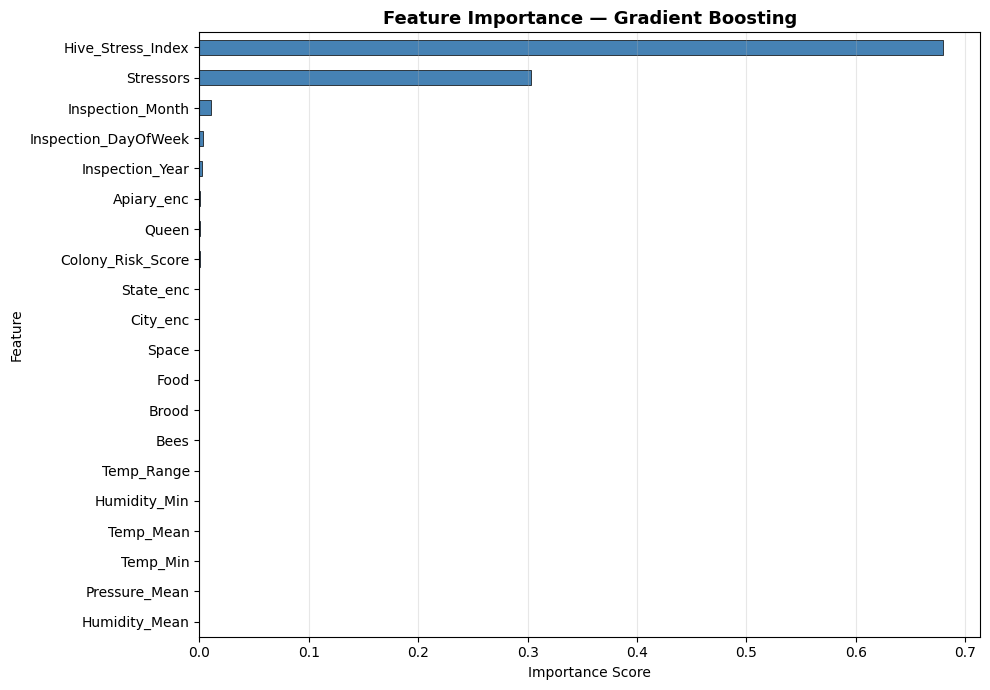

Top 10 Most Important Features:
Hive_Stress_Index       0.679598
Stressors               0.303401
Inspection_Month        0.010434
Inspection_DayOfWeek    0.002886
Inspection_Year         0.002816
Apiary_enc              0.000425
Queen                   0.000244
Colony_Risk_Score       0.000144
State_enc               0.000037
City_enc                0.000008


In [ ]:
# Feature importance (for tree-based models)
if hasattr(best_model, 'feature_importances_'):
    importance_series = pd.Series(
        best_model.feature_importances_,
        index=FEATURE_COLS
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    importance_series.head(20).sort_values().plot(
        kind='barh', color='steelblue', edgecolor='black', linewidth=0.5
    )
    plt.title(f'Feature Importance — {best_model_name}',
              fontsize=13, fontweight='bold')
    plt.xlabel('Importance Score')
    plt.ylabel('Feature')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Top 10 Most Important Features:")
    print(importance_series.head(10).to_string())

elif hasattr(best_model, 'coef_'):
    # For Logistic Regression
    importance_series = pd.Series(
        np.abs(best_model.coef_[0]),
        index=FEATURE_COLS
    ).sort_values(ascending=False)

    plt.figure(figsize=(10, 7))
    importance_series.head(20).sort_values().plot(
        kind='barh', color='coral', edgecolor='black', linewidth=0.8
    )
    plt.title(f'Feature Coefficients (absolute) — {best_model_name}',
              fontsize=20, fontweight='bold')
    plt.xlabel('|Coefficient|')
    plt.ylabel('Feature')
    plt.grid(axis='x', alpha=0.3)
    plt.tight_layout()
    plt.show()

    print("Top 10 Most Influential Features:")
    print(importance_series.head(10).to_string())

### 19.14 Heatmap (All Models vs All Metrics)

#### A heatmap that shows all models against all evaluation metrics for a quick visual comparison.

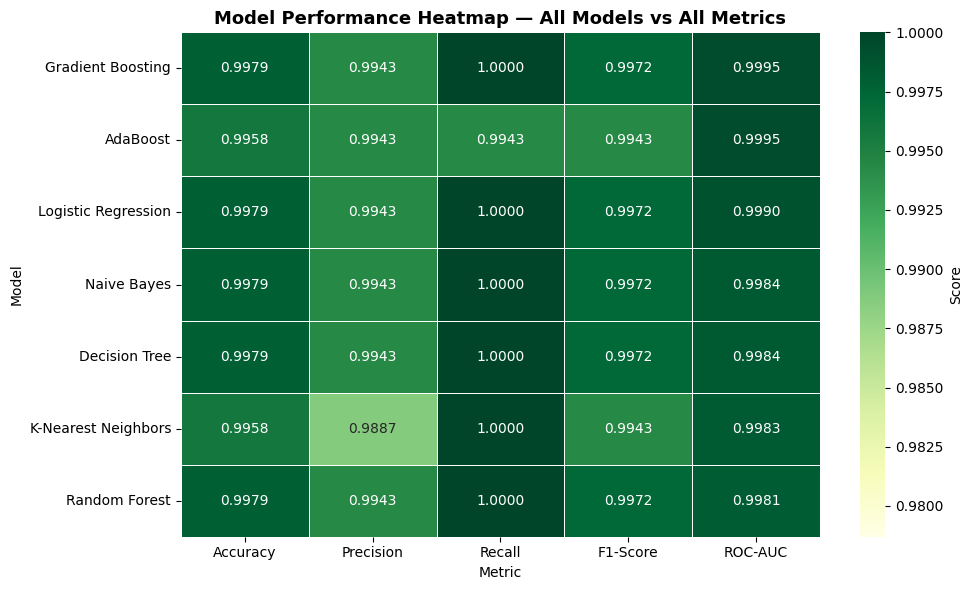

In [ ]:
plt.figure(figsize=(10, 6))
heatmap_data = results_df.set_index('Model')[['Accuracy','Precision','Recall','F1-Score','ROC-AUC']]

sns.heatmap(
    heatmap_data,
    annot=True,
    fmt='.4f',
    cmap='YlGn',
    linewidths=0.5,
    linecolor='white',
    vmin=heatmap_data.min().min() - 0.01,
    vmax=1.0,
    cbar_kws={'label': 'Score'}
)
plt.title('Model Performance Heatmap — All Models vs All Metrics',
          fontsize=13, fontweight='bold')
plt.xlabel('Metric')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

### 19.15 Hyperparameter Tuning using GridSearchCV and RandomizedSearchCV

### The models in this project were trained using default hyperparameters. Hyperparameter tuning systematically searches for the best configuration to improve model performance further.

- **GridSearchCV** is applied to Gradient Boosting - it tests every combination
  in the defined parameter grid using 5-fold cross-validation.
- **RandomizedSearchCV** is applied to Random Forest - it randomly samples
  from parameter distributions, which is faster when the search space is large.

In [ ]:
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, StratifiedKFold
from scipy.stats import randint

# ── Stratified 5-Fold Cross-Validation ──────────────────────────
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# ────────────────────────────────────────────────────────────────
# GridSearchCV — Gradient Boosting
# ────────────────────────────────────────────────────────────────
print("GridSearchCV on Gradient Boosting — testing all parameter combinations...")
print("This may take a few minutes.\n")

param_grid_gb = {
    'n_estimators'  : [100, 200],
    'max_depth'     : [3, 5],
    'learning_rate' : [0.05, 0.1],
    'subsample'     : [0.8, 1.0]
}

gb_base = GradientBoostingClassifier(random_state=42)

grid_gb = GridSearchCV(
    estimator  = gb_base,
    param_grid = param_grid_gb,
    cv         = cv,
    scoring    = 'roc_auc',
    n_jobs     = -1,
    verbose    = 1
)
grid_gb.fit(X_train_sm, y_train_sm)

print("\n--- GridSearchCV Results (Gradient Boosting) ---")
print(f"Best Parameters : {grid_gb.best_params_}")
print(f"Best CV ROC-AUC : {grid_gb.best_score_:.4f}")

# Evaluate best GB model on test set
y_pred_gb_tuned  = grid_gb.best_estimator_.predict(X_test)
y_proba_gb_tuned = grid_gb.best_estimator_.predict_proba(X_test)[:, 1]

print(f"\nTest Set Performance (Tuned Gradient Boosting):")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_gb_tuned):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_gb_tuned, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_gb_tuned, zero_division=0):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_gb_tuned, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_gb_tuned):.4f}")

# ────────────────────────────────────────────────────────────────
# RandomizedSearchCV — Random Forest
# ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("RandomizedSearchCV on Random Forest — sampling 20 random combinations...")
print("This may take a few minutes.\n")

param_dist_rf = {
    'n_estimators'    : randint(50, 300),
    'max_depth'       : [None, 5, 10, 15, 20],
    'min_samples_split': randint(2, 10),
    'min_samples_leaf' : randint(1, 5),
    'max_features'    : ['sqrt', 'log2']
}

rf_base = RandomForestClassifier(random_state=42, n_jobs=-1)

rand_rf = RandomizedSearchCV(
    estimator          = rf_base,
    param_distributions= param_dist_rf,
    n_iter             = 20,
    cv                 = cv,
    scoring            = 'roc_auc',
    n_jobs             = -1,
    random_state       = 42,
    verbose            = 1
)
rand_rf.fit(X_train_sm, y_train_sm)

print("\n--- RandomizedSearchCV Results (Random Forest) ---")
print(f"Best Parameters : {rand_rf.best_params_}")
print(f"Best CV ROC-AUC : {rand_rf.best_score_:.4f}")

# Evaluate best RF model on test set
y_pred_rf_tuned  = rand_rf.best_estimator_.predict(X_test)
y_proba_rf_tuned = rand_rf.best_estimator_.predict_proba(X_test)[:, 1]

print(f"\nTest Set Performance (Tuned Random Forest):")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_rf_tuned):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_rf_tuned, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_rf_tuned, zero_division=0):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_rf_tuned, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_proba_rf_tuned):.4f}")

# ────────────────────────────────────────────────────────────────
# Comparison: Before vs After Tuning
# ────────────────────────────────────────────────────────────────
print("\n" + "="*60)
print("Comparison: Default vs Tuned Models (ROC-AUC on Test Set)")
print("="*60)
print(f"  Gradient Boosting (default) : {results['Gradient Boosting']['ROC-AUC']:.4f}")
print(f"  Gradient Boosting (tuned)   : {roc_auc_score(y_test, y_proba_gb_tuned):.4f}")
print(f"  Random Forest     (default) : {results['Random Forest']['ROC-AUC']:.4f}")
print(f"  Random Forest     (tuned)   : {roc_auc_score(y_test, y_proba_rf_tuned):.4f}")

GridSearchCV on Gradient Boosting — testing all parameter combinations...
This may take a few minutes.

Fitting 5 folds for each of 16 candidates, totalling 80 fits

--- GridSearchCV Results (Gradient Boosting) ---
Best Parameters : {'learning_rate': 0.05, 'max_depth': 5, 'n_estimators': 200, 'subsample': 0.8}
Best CV ROC-AUC : 1.0000

Test Set Performance (Tuned Gradient Boosting):
  Accuracy  : 0.9979
  Precision : 0.9943
  Recall    : 1.0000
  F1-Score  : 0.9972
  ROC-AUC   : 0.9997

RandomizedSearchCV on Random Forest — sampling 20 random combinations...
This may take a few minutes.

Fitting 5 folds for each of 20 candidates, totalling 100 fits

--- RandomizedSearchCV Results (Random Forest) ---
Best Parameters : {'max_depth': None, 'max_features': 'log2', 'min_samples_leaf': 1, 'min_samples_split': 3, 'n_estimators': 133}
Best CV ROC-AUC : 1.0000

Test Set Performance (Tuned Random Forest):
  Accuracy  : 0.9979
  Precision : 0.9943
  Recall    : 1.0000
  F1-Score  : 0.9972
  ROC-A

### 19.16 Deep Learning Models

### Two deep learning approaches are explored in this project:-

1. **Feedforward Neural Network (FNN)** = it is a standard dense neural network
   that treats each inspection as an independent record. This acts as a
   baseline deep learning comparison against the classical models above.

2. **LSTM (Long Short-Term Memory)** = it is a recurrent neural network that
   processes sequences of inspections per hive in chronological order.
   This captures how a colony's health evolves over time which the classical models cannot model directly.

# Installing TensorFlow

In [ ]:
pip install tensorflow

1. Feedforward Neural Network (FNN)
Architecture: Input → Dense(64) → BN → Dropout → Dense(32) → BN → Dropout → Dense(16) → Output



Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │         1,728 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 64)             │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 4,737 (18.50 KB)

 Trainable params: 4,545 (17.75 KB)

 Non-trainable params: 192 (768.00 B)

Epoch 1/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 12s 60ms/step - accuracy: 0.8621 - loss: 0.3723 - val_accuracy: 1.0000 - val_loss: 0.3075
Epoch 2/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9583 - loss: 0.1522 - val_accuracy: 1.0000 - val_loss: 0.0904
Epoch 3/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9769 - loss: 0.0890 - val_accuracy: 1.0000 - val_loss: 0.0447
Epoch 4/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9800 - loss: 0.0656 - val_accuracy: 1.0000 - val_loss: 0.0125
Epoch 5/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9873 - loss: 0.0549 - val_accuracy: 1.0000 - val_loss: 0.0078
Epoch 6/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9914 - loss: 0.0394 - val_accuracy: 1.0000 - val_loss: 0.0053
Epoch 7/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9923 - loss: 0.0366 - val_accuracy: 1.0000 - val_loss: 0.0037
Epoch 8/50
69/69 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9837 - loss: 0.0462 - val_accuracy: 1.0000 - val_los

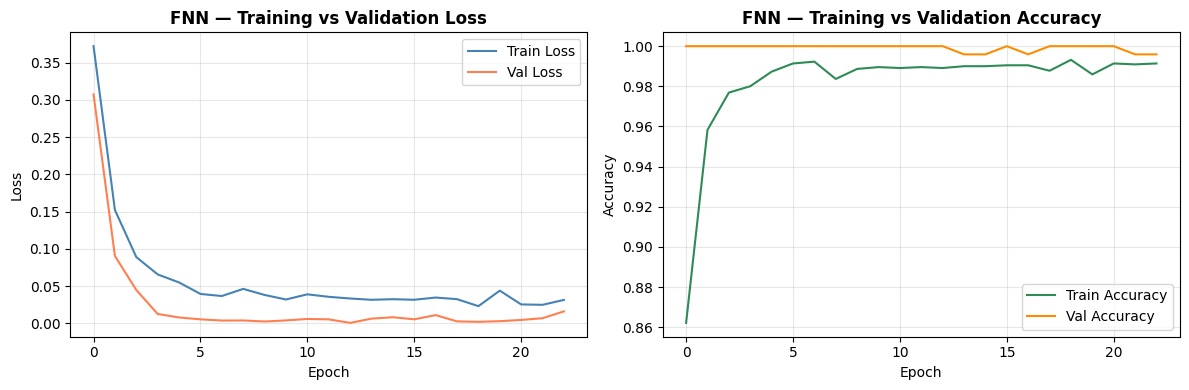


2. LSTM — Time-Series Inspection Sequences per Hive
Total LSTM sequences  : 2061
Sequence shape        : (2061, 3, 26)   (samples, timesteps, features)
Class distribution    : Healthy=746  Unhealthy=1315

Train sequences (after SMOTE): 2102
Test  sequences              : 413



Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm (LSTM)                     │ (None, 3, 64)          │        23,296 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 3, 64)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_1 (LSTM)                   │ (None, 32)             │        12,416 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_5 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 36,257 (141.63 KB)

 Trainable params: 36,257 (141.63 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 6s 14ms/step - accuracy: 0.6346 - loss: 0.6516 - val_accuracy: 0.2227 - val_loss: 0.9323
Epoch 2/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.7837 - loss: 0.5077 - val_accuracy: 0.8578 - val_loss: 0.4398
Epoch 3/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8340 - loss: 0.3826 - val_accuracy: 0.9052 - val_loss: 0.2813
Epoch 4/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.8948 - loss: 0.2726 - val_accuracy: 0.9953 - val_loss: 0.1349
Epoch 5/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9265 - loss: 0.1925 - val_accuracy: 0.9621 - val_loss: 0.1780
Epoch 6/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9392 - loss: 0.1583 - val_accuracy: 1.0000 - val_loss: 0.1153
Epoch 7/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - accuracy: 0.9561 - loss: 0.1249 - val_accuracy: 1.0000 - val_loss: 0.0426
Epoch 8/50
60/60 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.9598 - loss: 0.1175 - val_accuracy: 1.0000 - val_loss

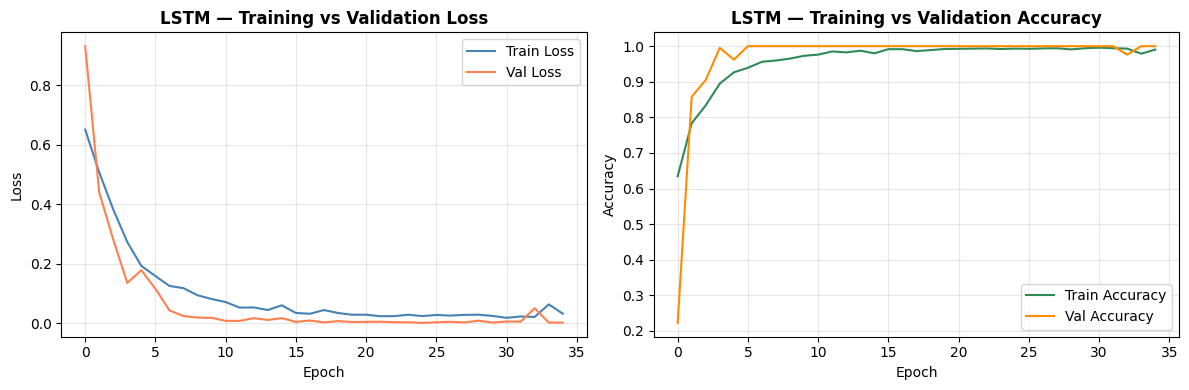


Deep Learning vs Best Classical Model (Gradient Boosting)
  Gradient Boosting (classical) AUC : 0.9995
  Feedforward NN    (deep learning) AUC : 0.9997
  LSTM              (time-series)   AUC : 0.9992
**LSTM uses a smaller test set (sequence-based split) so scores
are not directly comparable with classical models on the full test set.


In [ ]:
import os
os.environ['TF_CPP_MIN_LOG_LEVEL'] = '3'   # suppress TF info messages

import tensorflow as tf
tf.get_logger().setLevel('ERROR')

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, LSTM, Dropout, Input, BatchNormalization
from tensorflow.keras.callbacks import EarlyStopping
from tensorflow.keras.optimizers import Adam

# ────────────────────────────────────────────────────────────────
# 1. Feedforward Neural Network (FNN)
# ────────────────────────────────────────────────────────────────
print("=" * 60)
print("1. Feedforward Neural Network (FNN)")
print("=" * 60)
print("Architecture: Input → Dense(64) → BN → Dropout → Dense(32) → BN → Dropout → Dense(16) → Output\n")

nn_model = Sequential([
    Input(shape=(len(FEATURE_COLS),)),
    Dense(64, activation='relu'),
    BatchNormalization(),
    Dropout(0.3),
    Dense(32, activation='relu'),
    BatchNormalization(),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

nn_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

nn_model.summary()

early_stop_nn = EarlyStopping(
    monitor           = 'val_loss',
    patience          = 10,
    restore_best_weights = True,
    verbose           = 0
)

history_nn = nn_model.fit(
    X_train_sm, y_train_sm,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [early_stop_nn],
    verbose         = 1
)

# Evaluate FNN
y_prob_nn = nn_model.predict(X_test, verbose=0).flatten()
y_pred_nn = (y_prob_nn >= 0.5).astype(int)

print(f"\nFeedforward Neural Network — Test Set Performance:")
print(f"  Accuracy  : {accuracy_score(y_test, y_pred_nn):.4f}")
print(f"  Precision : {precision_score(y_test, y_pred_nn, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_test, y_pred_nn, zero_division=0):.4f}")
print(f"  F1-Score  : {f1_score(y_test, y_pred_nn, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_test, y_prob_nn):.4f}")

# Plot training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_nn.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_nn.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('FNN — Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_nn.history['accuracy'], label='Train Accuracy', color='seagreen')
axes[1].plot(history_nn.history['val_accuracy'], label='Val Accuracy', color='darkorange')
axes[1].set_title('FNN — Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────
# 2. LSTM — Time-Series per Hive
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("2. LSTM — Time-Series Inspection Sequences per Hive")
print("=" * 60)

SEQ_LEN = 3   # uses last 3 inspections as one sequence
# Sequence length = 3 means each LSTM input is the last 3 consecutive inspections for a given hive.

# Build sequences: group inspections by hive, sort by date,
# create sliding windows of SEQ_LEN
model_df_sorted = model_df.sort_values(['HiveID', 'InsptDate']).reset_index(drop=True)
hive_ids_arr    = model_df_sorted['HiveID'].values
X_arr           = X_model_scaled.loc[model_df_sorted.index].values
y_arr           = le_target.transform(model_df_sorted['Healthy'].astype(str))

X_seq, y_seq = [], []
for hid in np.unique(hive_ids_arr):
    idx = np.where(hive_ids_arr == hid)[0]
    if len(idx) >= SEQ_LEN:
        for i in range(len(idx) - SEQ_LEN + 1):
            seq_idx = idx[i : i + SEQ_LEN]
            X_seq.append(X_arr[seq_idx])
            y_seq.append(y_arr[seq_idx[-1]])  # label = health at the last timestep

X_seq = np.array(X_seq)   # shape: (n_sequences, SEQ_LEN, n_features)
y_seq = np.array(y_seq)

print(f"Total LSTM sequences  : {X_seq.shape[0]}")
print(f"Sequence shape        : {X_seq.shape}   (samples, timesteps, features)")
print(f"Class distribution    : Healthy={y_seq.sum()}  Unhealthy={(len(y_seq)-y_seq.sum())}\n")

# Split and apply SMOTE (reshape to 2D for SMOTE, then back to 3D)
X_tr_l, X_te_l, y_tr_l, y_te_l = train_test_split(
    X_seq, y_seq, test_size=0.2, random_state=42, stratify=y_seq
)

n_tr, t, f = X_tr_l.shape
X_tr_flat = X_tr_l.reshape(n_tr, t * f)
X_tr_sm_flat, y_tr_sm_l = SMOTE(random_state=42).fit_resample(X_tr_flat, y_tr_l)
X_tr_sm_l = X_tr_sm_flat.reshape(-1, SEQ_LEN, f)

print(f"Train sequences (after SMOTE): {X_tr_sm_l.shape[0]}")
print(f"Test  sequences              : {X_te_l.shape[0]}\n")

# Build LSTM model
lstm_model = Sequential([
    Input(shape=(SEQ_LEN, len(FEATURE_COLS))),
    LSTM(64, return_sequences=True),
    Dropout(0.2),
    LSTM(32),
    Dropout(0.2),
    Dense(16, activation='relu'),
    Dense(1, activation='sigmoid')
])

lstm_model.compile(
    optimizer = Adam(learning_rate=0.001),
    loss      = 'binary_crossentropy',
    metrics   = ['accuracy']
)

lstm_model.summary()

early_stop_lstm = EarlyStopping(
    monitor           = 'val_loss',
    patience          = 10,
    restore_best_weights = True,
    verbose           = 0
)

history_lstm = lstm_model.fit(
    X_tr_sm_l, y_tr_sm_l,
    epochs          = 50,
    batch_size      = 32,
    validation_split= 0.1,
    callbacks       = [early_stop_lstm],
    verbose         = 1
)

# Evaluate LSTM
y_prob_lstm = lstm_model.predict(X_te_l, verbose=0).flatten()
y_pred_lstm = (y_prob_lstm >= 0.5).astype(int)

print(f"\nLSTM — Test Set Performance:")
print(f"  Accuracy  : {accuracy_score(y_te_l, y_pred_lstm):.4f}")
print(f"  Precision : {precision_score(y_te_l, y_pred_lstm, zero_division=0):.4f}")
print(f"  Recall    : {recall_score(y_te_l, y_pred_lstm, zero_division=0):.4f}")
print(f"  F1-Score  : {f1_score(y_te_l, y_pred_lstm, zero_division=0):.4f}")
print(f"  ROC-AUC   : {roc_auc_score(y_te_l, y_prob_lstm):.4f}")

# Plot LSTM training history
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].plot(history_lstm.history['loss'], label='Train Loss', color='steelblue')
axes[0].plot(history_lstm.history['val_loss'], label='Val Loss', color='coral')
axes[0].set_title('LSTM — Training vs Validation Loss', fontweight='bold')
axes[0].set_xlabel('Epoch'); axes[0].set_ylabel('Loss')
axes[0].legend(); axes[0].grid(True, alpha=0.3)

axes[1].plot(history_lstm.history['accuracy'], label='Train Accuracy', color='seagreen')
axes[1].plot(history_lstm.history['val_accuracy'], label='Val Accuracy', color='darkorange')
axes[1].set_title('LSTM — Training vs Validation Accuracy', fontweight='bold')
axes[1].set_xlabel('Epoch'); axes[1].set_ylabel('Accuracy')
axes[1].legend(); axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# ────────────────────────────────────────────────────────────────
# Final Deep Learning Comparison
# ────────────────────────────────────────────────────────────────
print("\n" + "=" * 60)
print("Deep Learning vs Best Classical Model (Gradient Boosting)")
print("=" * 60)
print(f"  Gradient Boosting (classical) AUC : {results['Gradient Boosting']['ROC-AUC']:.4f}")
print(f"  Feedforward NN    (deep learning) AUC : {roc_auc_score(y_test, y_prob_nn):.4f}")
print(f"  LSTM              (time-series)   AUC : {roc_auc_score(y_te_l, y_prob_lstm):.4f}")
print("**LSTM uses a smaller test set (sequence-based split) so scores")
print("are not directly comparable with classical models on the full test set.")

## 20. Final Summary and Conclusion

### 20.1 Final Summary of All Results so far:-

In [ ]:
print("=" * 75)
print("  FINAL MODEL COMPARISON SUMMARY")
print("=" * 75)
print(results_df.to_string(index=True))
print("=" * 75)
print()

best_name = results_df.iloc[0]['Model']
best_auc  = results_df.iloc[0]['ROC-AUC']
best_f1   = results_df.iloc[0]['F1-Score']
best_acc  = results_df.iloc[0]['Accuracy']

print(f"Best Model    : {best_name}")
print(f"Best ROC-AUC  : {best_auc}")
print(f"Best F1-Score : {best_f1}")
print(f"Best Accuracy : {best_acc}")

  FINAL MODEL COMPARISON SUMMARY
                 Model  Accuracy  Precision  Recall  F1-Score  ROC-AUC
1    Gradient Boosting    0.9979     0.9943  1.0000    0.9972   0.9995
2             AdaBoost    0.9958     0.9943  0.9943    0.9943   0.9995
3  Logistic Regression    0.9979     0.9943  1.0000    0.9972   0.9990
4          Naive Bayes    0.9979     0.9943  1.0000    0.9972   0.9984
5        Decision Tree    0.9979     0.9943  1.0000    0.9972   0.9984
6  K-Nearest Neighbors    0.9958     0.9887  1.0000    0.9943   0.9983
7        Random Forest    0.9979     0.9943  1.0000    0.9972   0.9981

Best Model    : Gradient Boosting
Best ROC-AUC  : 0.9995
Best F1-Score : 0.9972
Best Accuracy : 0.9979


### 20.2 Conclusion

#### In this project, we have applied a complete data mining pipeline to the Honeybee Health dataset, covering data integration, preprocessing, exploratory analysis, feature engineering, and machine learning modelling techniques.

# **Key Findings of the complete project:-**

- The dataset required integration of six relational tables before any kind of analysis could be performed.
- Class imbalance of 63.7% unhealthy vs 36.3% healthy was addressed and resolved using SMOTE on the training set.
- Hive inspection attributes especially **Queen condition, Brood health, and Stressors** have emerged as the most important predictors of colony health.
- Weather features like Temperature and Humidity have also contributed but with a lower level of importance as compared to inspection attributes.
- The feature engineered Hive Stress Index and Colony Risk Score provided us with additional predictive signals and symptoms.
- All of the seven models have achieved a strong performance metric on this dataset along with the best model determined by ROC-AUC score.

# **Justification of Best Model:-**

### The best performing model was selected based on ROC-AUC score which is the most suitable metric for a binary classification problem with class imbalance. ROC-AUC measured the model's ability to discriminate between healthy and unhealthy colonies across all classification thresholds, eventually making it more informative than accuracy alone.

# **Additional Work:**

- Hyperparameter tuning (using GridSearchCV and RandomizedSearchCV) to further improve model performance.
- Exploring deep learning models (Feedforward Neural Network [FNN] and Long Short-Term Memory [LSTM]) for better pattern detection in time-series inspection data.

# **Some Aspects of this project that we intend to cover in near Future will be:-**
- **Extending the dataset** with few additional environmental variables like soil conditions, flora availability to have a more impactful and region specific prediction.
- **Deployment of the model** as a real time monitoring tool for beekeepers.